# MD Results Visualization and Evaluation

This notebook visualizes the CSV outputs generated by the MD analysis notebook. It does not recompute trajectory-based features. Instead, it loads precomputed result tables from `results/md_feature_analysis` and generates summary plots for stability, catalytic geometry, substrate interactions, feature robustness and preliminary MD-based ranking.

## Setup

Define project paths, import libraries and provide helper functions for loading result tables only if they exist.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/home/dwp46550/ba_nylon").resolve()
RESULT_DIR = PROJECT_ROOT / "results" / "md_feature_analysis"
print(f"Using result directory: {RESULT_DIR}")

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

def load_csv_if_exists(filename, result_dir=RESULT_DIR):
    path = result_dir / filename
    if path.exists():
        df = pd.read_csv(path)
        print(f"Loaded {filename}: {df.shape}")
        return df
    print(f"Missing: {filename}")
    return pd.DataFrame()

def require_columns(df, columns, table_name="table"):
    missing = [c for c in columns if c not in df.columns]
    if missing:
        print(f"Skipping {table_name}. Missing columns: {missing}")
        return False
    return True


Using result directory: /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/md_feature_analysis


## Load result tables

All available CSV outputs from the analysis notebook are loaded here. Missing files are skipped gracefully.

In [2]:
rmsd_framewise = load_csv_if_exists("rmsd_framewise.csv")
rmsd_replicate = load_csv_if_exists("rmsd_replicate.csv")
rmsd_variant_by_condition = load_csv_if_exists("rmsd_variant_by_condition.csv")

rmsf_replicate = load_csv_if_exists("rmsf_replicate.csv")
rmsf_variant_by_condition = load_csv_if_exists("rmsf_variant_by_condition.csv")

substrate_contacts_replicate = load_csv_if_exists("substrate_contacts_replicate.csv")
substrate_contacts_variant = load_csv_if_exists("substrate_contacts_variant_by_condition.csv")

productive_geometry_framewise = load_csv_if_exists("productive_geometry_framewise.csv")
productive_geometry_replicate = load_csv_if_exists("productive_geometry_replicate.csv")

triad_replicate = load_csv_if_exists("triad_stability_replicate.csv")
pocket_distance_replicate = load_csv_if_exists("pocket_distance_proxies_replicate.csv")
substrate_dynamics_replicate = load_csv_if_exists("substrate_dynamics_replicate.csv")
polar_contacts_replicate = load_csv_if_exists("polar_contacts_replicate.csv")

md_filter_features_replicate = load_csv_if_exists("md_filter_features_replicate.csv")
replicate_robustness = load_csv_if_exists("md_filter_feature_replicate_robustness.csv")
score_df = load_csv_if_exists("md_filter_features_with_score_v01.csv")


Loaded rmsd_framewise.csv: (15018, 7)
Loaded rmsd_replicate.csv: (18, 8)
Loaded rmsd_variant_by_condition.csv: (6, 5)
Loaded rmsf_replicate.csv: (23904, 8)
Loaded rmsf_variant_by_condition.csv: (7968, 8)
Loaded substrate_contacts_replicate.csv: (627, 12)
Loaded substrate_contacts_variant_by_condition.csv: (249, 10)
Loaded productive_geometry_framewise.csv: (9012, 13)
Loaded productive_geometry_replicate.csv: (12, 27)
Loaded triad_stability_replicate.csv: (12, 19)
Loaded pocket_distance_proxies_replicate.csv: (12, 23)
Loaded substrate_dynamics_replicate.csv: (12, 11)
Loaded polar_contacts_replicate.csv: (12, 71)
Loaded md_filter_features_replicate.csv: (12, 151)
Loaded md_filter_feature_replicate_robustness.csv: (592, 7)
Loaded md_filter_features_with_score_v01.csv: (12, 167)


# 1. Global structural stability

Backbone RMSD summarizes global trajectory stability and helps identify problematic replicates or variants.

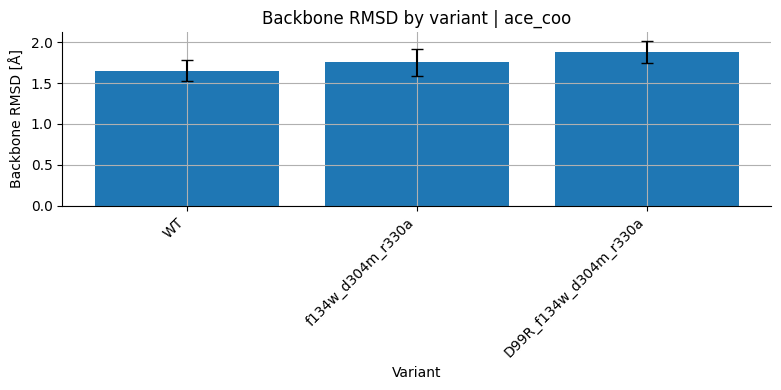

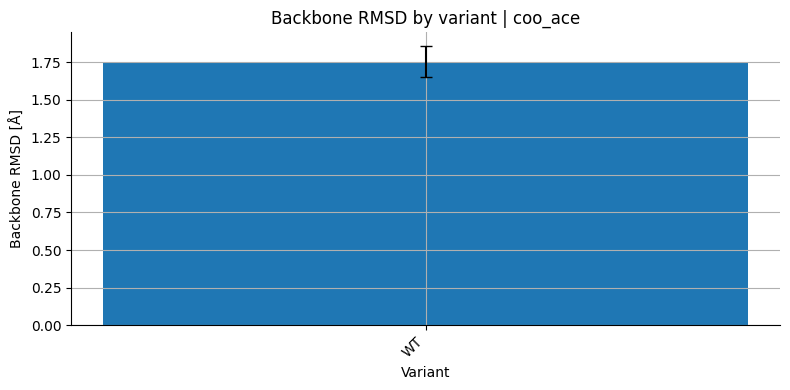

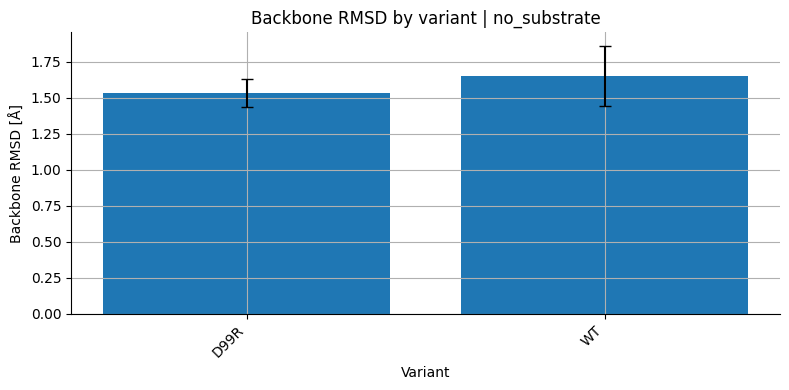

In [3]:
if not rmsd_variant_by_condition.empty and require_columns(rmsd_variant_by_condition, ["condition", "variant", "rmsd_mean_over_replicates_A", "rmsd_sd_between_replicates_A"], "rmsd_variant_by_condition"):
    for condition_name in sorted(rmsd_variant_by_condition["condition"].unique()):
        plot_df = rmsd_variant_by_condition[rmsd_variant_by_condition["condition"] == condition_name].copy()
        plot_df = plot_df.sort_values("rmsd_mean_over_replicates_A")

        plt.figure(figsize=(8, 4))
        plt.bar(plot_df["variant"], plot_df["rmsd_mean_over_replicates_A"], yerr=plot_df["rmsd_sd_between_replicates_A"], capsize=4)
        plt.ylabel("Backbone RMSD [Å]")
        plt.xlabel("Variant")
        plt.title(f"Backbone RMSD by variant | {condition_name}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


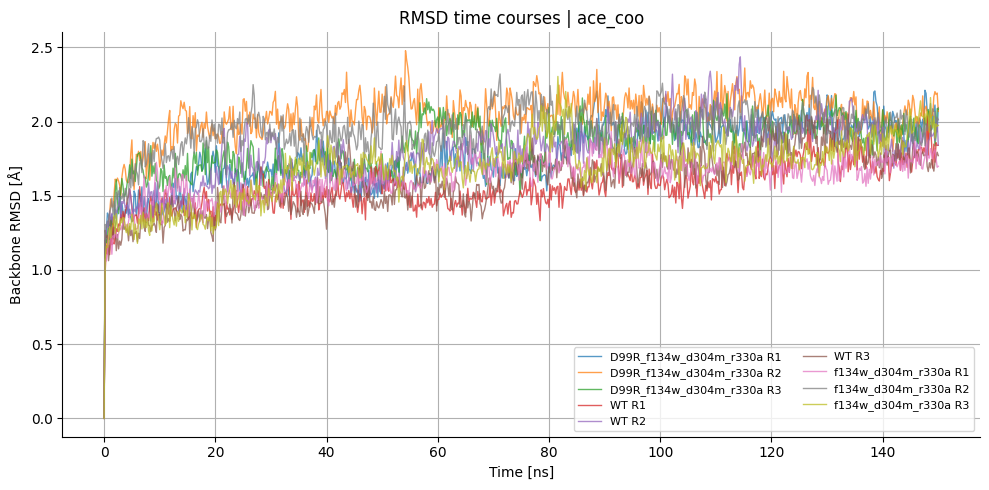

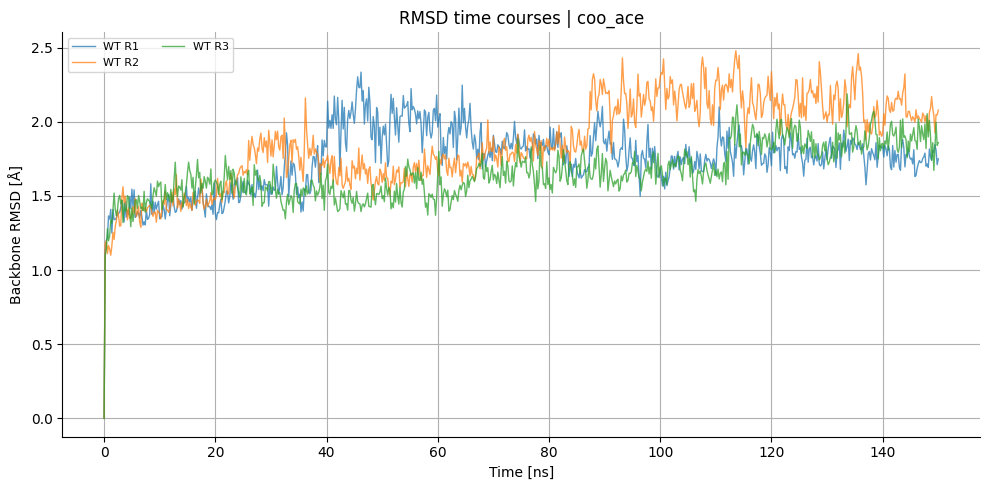

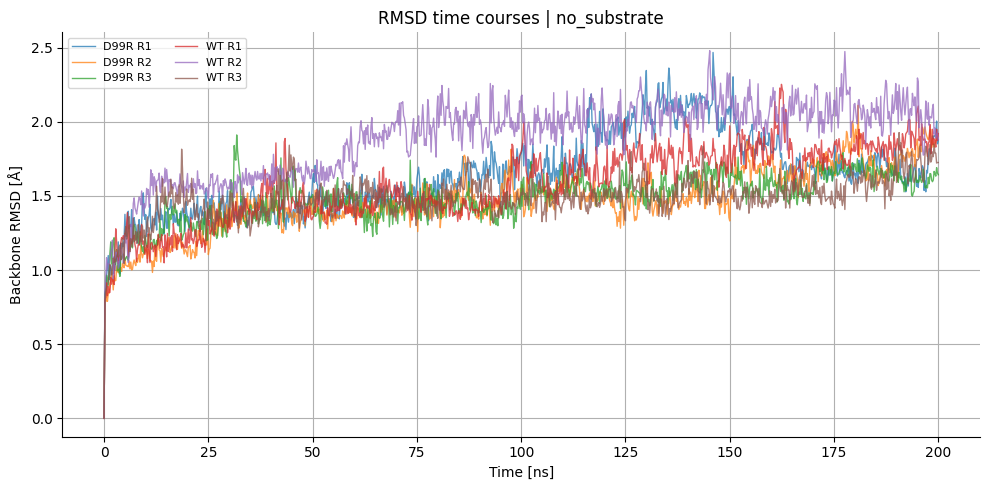

In [4]:
if not rmsd_framewise.empty and require_columns(rmsd_framewise, ["condition", "variant", "replicate", "time_ps", "rmsd_A"], "rmsd_framewise"):
    for condition_name in sorted(rmsd_framewise["condition"].unique()):
        plot_df = rmsd_framewise[rmsd_framewise["condition"] == condition_name].copy()
        plt.figure(figsize=(10, 5))
        for (variant, replicate), group in plot_df.groupby(["variant", "replicate"]):
            group = group.sort_values("time_ps")
            plt.plot(group["time_ps"] / 1000, group["rmsd_A"], linewidth=1, alpha=0.75, label=f"{variant} R{replicate}")
        plt.xlabel("Time [ns]")
        plt.ylabel("Backbone RMSD [Å]")
        plt.title(f"RMSD time courses | {condition_name}")
        plt.legend(fontsize=8, ncol=2)
        plt.tight_layout()
        plt.show()


# 2. Local flexibility

RMSF profiles describe residue-level flexibility and can reveal stabilized or destabilized pocket regions.

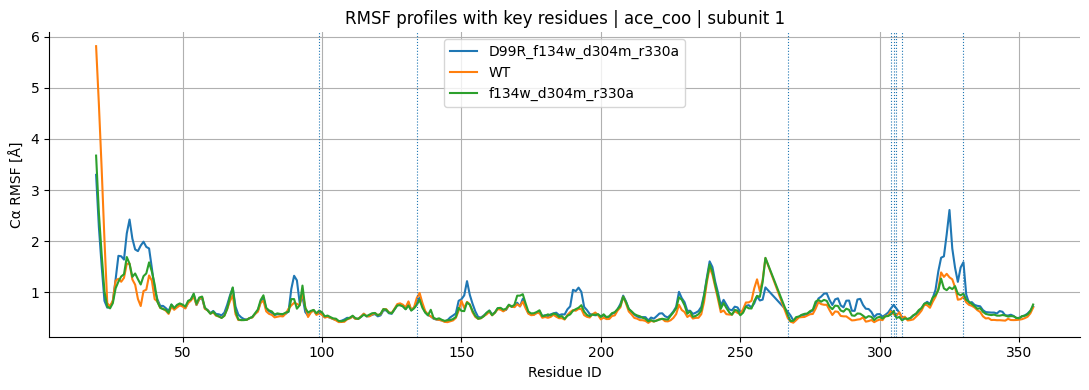

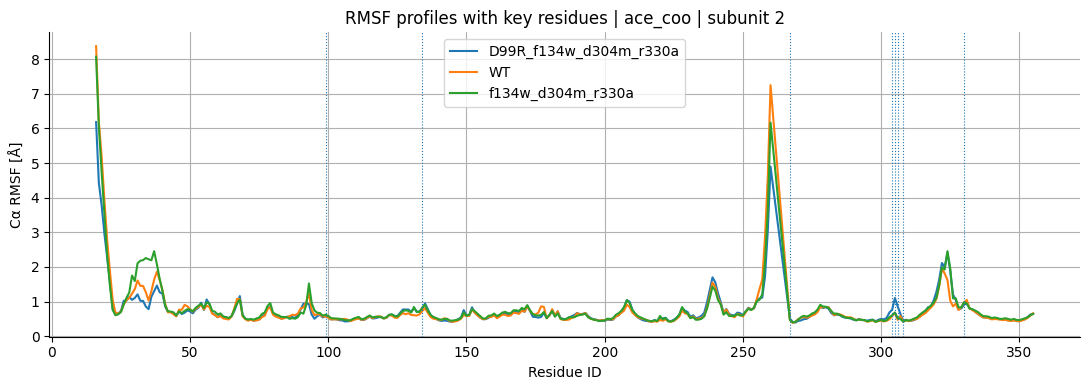

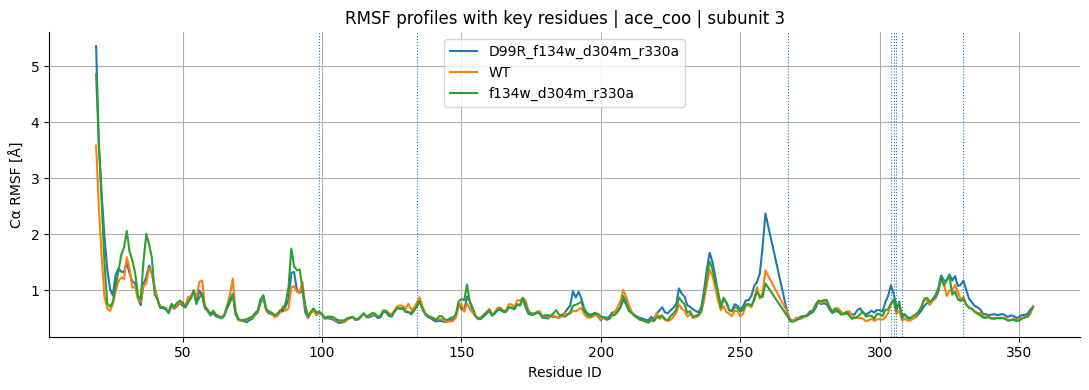

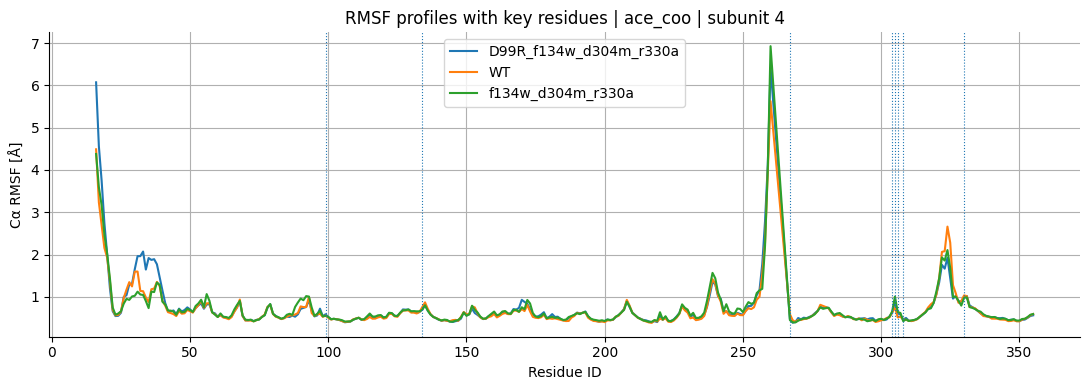

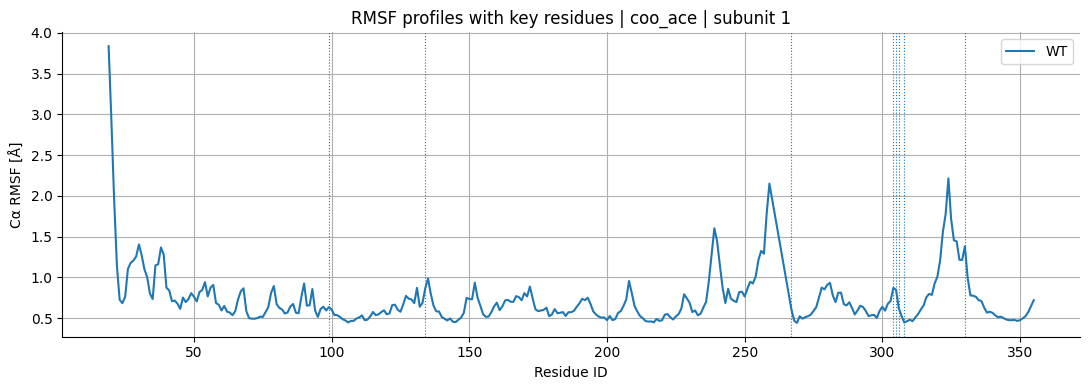

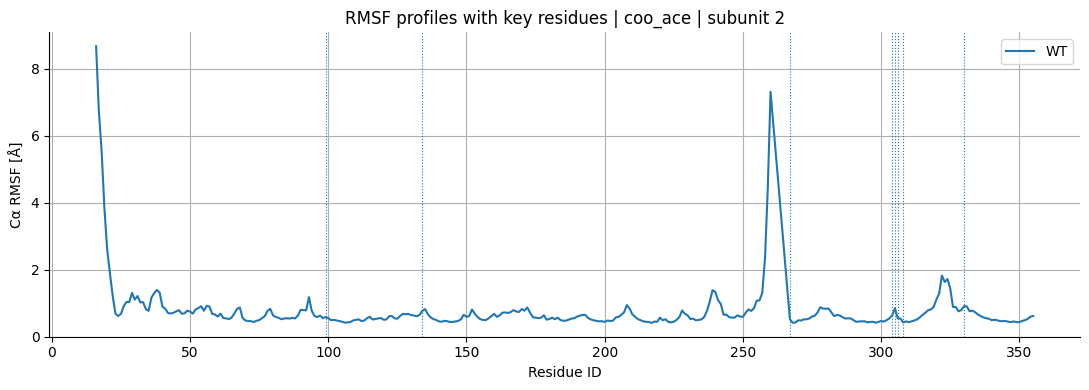

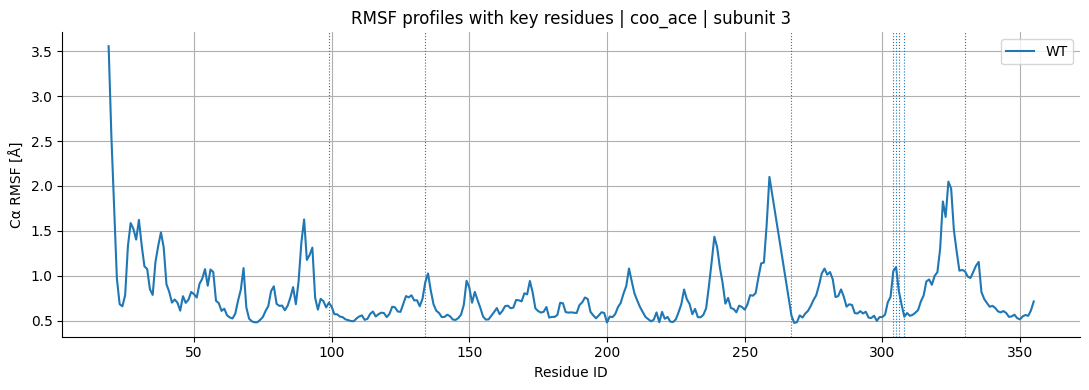

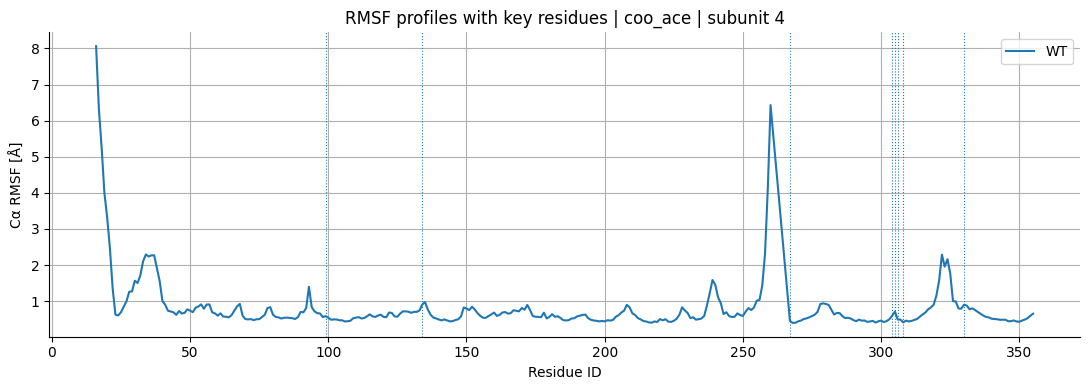

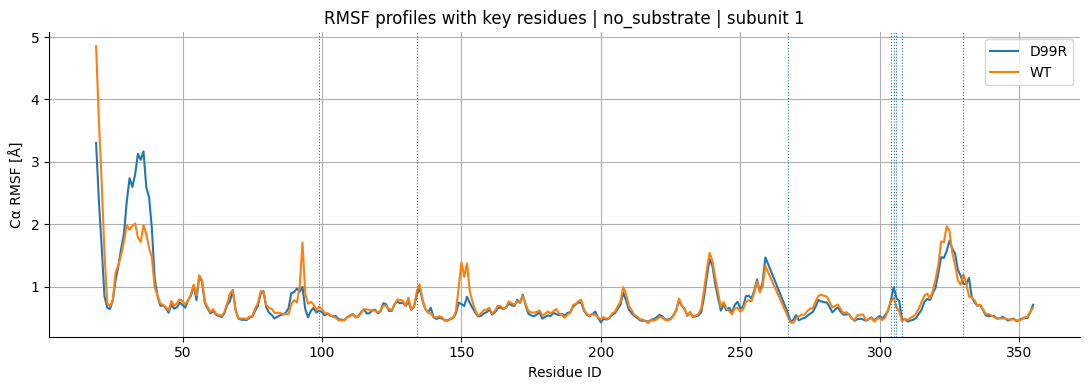

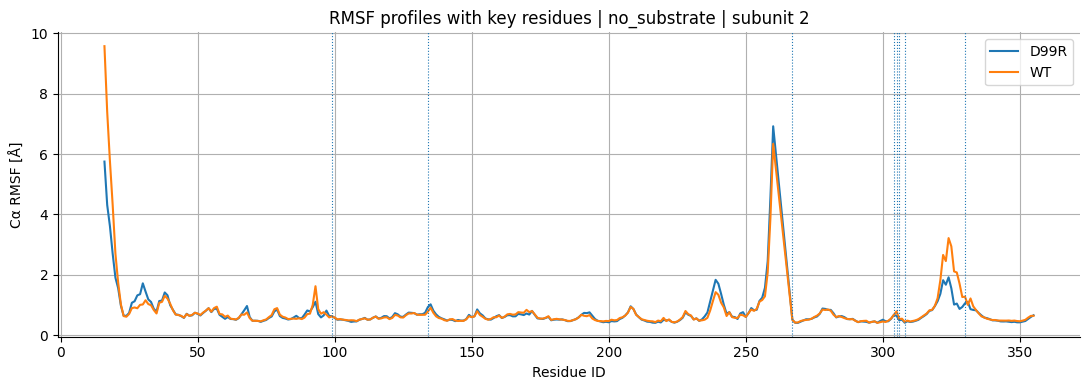

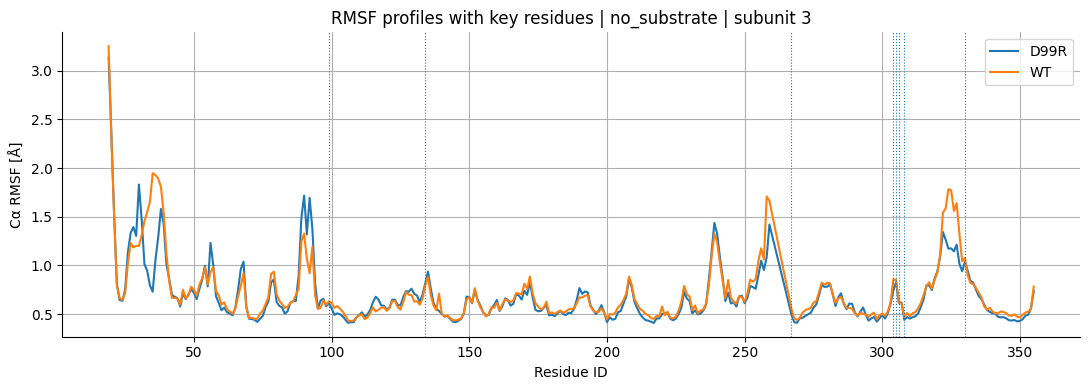

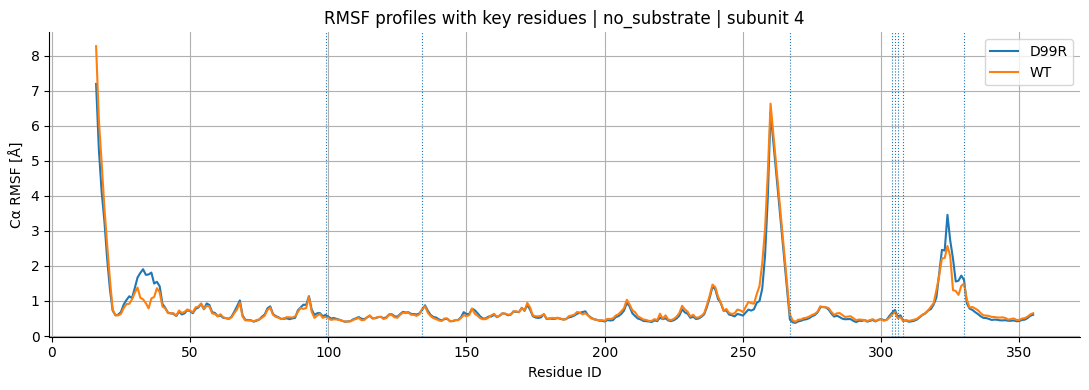

In [5]:
highlight_residues = [99, 134, 267, 304, 305, 306, 308, 330]

if not rmsf_variant_by_condition.empty and require_columns(rmsf_variant_by_condition, ["condition", "variant", "subunit_id", "resid", "rmsf_mean_A"], "rmsf_variant_by_condition"):
    for condition_name in sorted(rmsf_variant_by_condition["condition"].unique()):
        condition_df = rmsf_variant_by_condition[rmsf_variant_by_condition["condition"] == condition_name].copy()
        for subunit_id in sorted(condition_df["subunit_id"].unique()):
            subunit_df = condition_df[condition_df["subunit_id"] == subunit_id].copy()
            plt.figure(figsize=(11, 4))
            for variant in sorted(subunit_df["variant"].unique()):
                plot_df = subunit_df[subunit_df["variant"] == variant].sort_values("resid")
                plt.plot(plot_df["resid"], plot_df["rmsf_mean_A"], label=variant, linewidth=1.5)
            for resid in highlight_residues:
                plt.axvline(resid, linestyle=":", linewidth=0.8)
            plt.xlabel("Residue ID")
            plt.ylabel("Cα RMSF [Å]")
            plt.title(f"RMSF profiles with key residues | {condition_name} | subunit {subunit_id}")
            plt.legend()
            plt.tight_layout()
            plt.show()


In [6]:
if not rmsf_variant_by_condition.empty and "rmsf_mean_A" in rmsf_variant_by_condition.columns:
    TOP_N = 10
    peak_df = (
        rmsf_variant_by_condition
        .groupby(["condition", "variant"], group_keys=False)
        .apply(lambda x: x.nlargest(TOP_N, "rmsf_mean_A"))
        .reset_index(drop=True)
    )
    display(peak_df[[c for c in ["condition", "variant", "subunit_id", "resid", "resname", "rmsf_mean_A", "rmsf_sd_A", "n_replicates"] if c in peak_df.columns]])


/w0/tmp/slurm_dwp46550.541736/ipykernel_199985/96657996.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmsf_variant_by_condition


,condition,variant,subunit_id,resid,resname,rmsf_mean_A,rmsf_sd_A,n_replicates
0,ace_coo,D99R_f134w_d304m_r330a,4,260,PRO,6.419956,0.347524,3
1,ace_coo,D99R_f134w_d304m_r330a,2,16,ILE,6.180846,3.339569,3
2,ace_coo,D99R_f134w_d304m_r330a,4,16,ILE,6.071845,4.109070,3
3,ace_coo,D99R_f134w_d304m_r330a,3,19,ASP,5.359540,1.645447,3
4,ace_coo,D99R_f134w_d304m_r330a,2,260,PRO,4.894817,1.267059,3
5,ace_coo,D99R_f134w_d304m_r330a,4,17,ALA,4.564840,3.037345,3
6,ace_coo,D99R_f134w_d304m_r330a,2,17,ALA,4.421688,2.295693,3
7,ace_coo,D99R_f134w_d304m_r330a,4,259,PRO,4.129069,0.657067,3
8,ace_coo,D99R_f134w_d304m_r330a,2,18,VAL,3.782246,1.852054,3
9,ace_coo,D99R_f134w_d304m_r330a,4,18,VAL,3.746679,2.557183,3


# 3. Productive catalytic geometry

This section visualizes features related to productive PA6 positioning near catalytic Thr267.

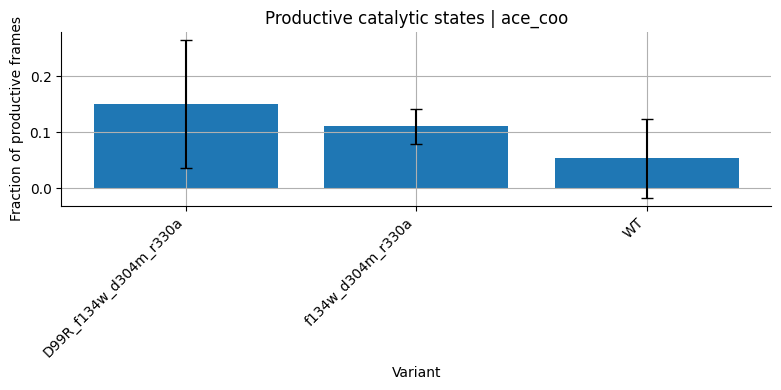

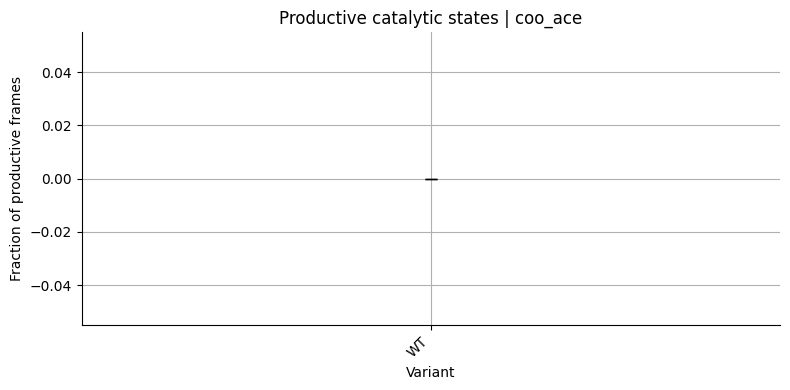

In [7]:
source_df = productive_geometry_replicate if not productive_geometry_replicate.empty else md_filter_features_replicate
productive_fraction_col = None
for candidate in ["productive_state_mean", "productive_fraction"]:
    if candidate in source_df.columns:
        productive_fraction_col = candidate
        break

if productive_fraction_col is not None:
    plot_df = (
        source_df
        .groupby(["condition", "variant"], as_index=False)
        .agg(productive_fraction_mean=(productive_fraction_col, "mean"), productive_fraction_sd=(productive_fraction_col, "std"), n_replicates=("replicate", "count"))
    )
    for condition_name in sorted(plot_df["condition"].unique()):
        condition_df = plot_df[plot_df["condition"] == condition_name].copy().sort_values("productive_fraction_mean", ascending=False)
        plt.figure(figsize=(8, 4))
        plt.bar(condition_df["variant"], condition_df["productive_fraction_mean"], yerr=condition_df["productive_fraction_sd"], capsize=4)
        plt.ylabel("Fraction of productive frames")
        plt.xlabel("Variant")
        plt.title(f"Productive catalytic states | {condition_name}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
else:
    print("No productive-state column found.")


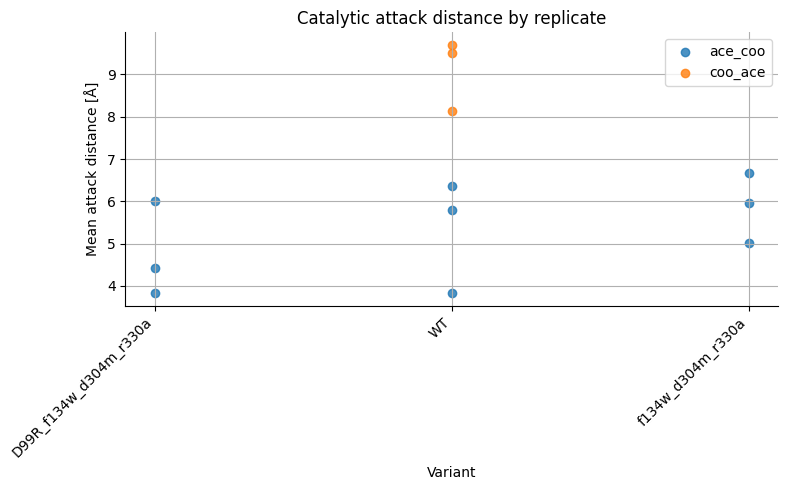

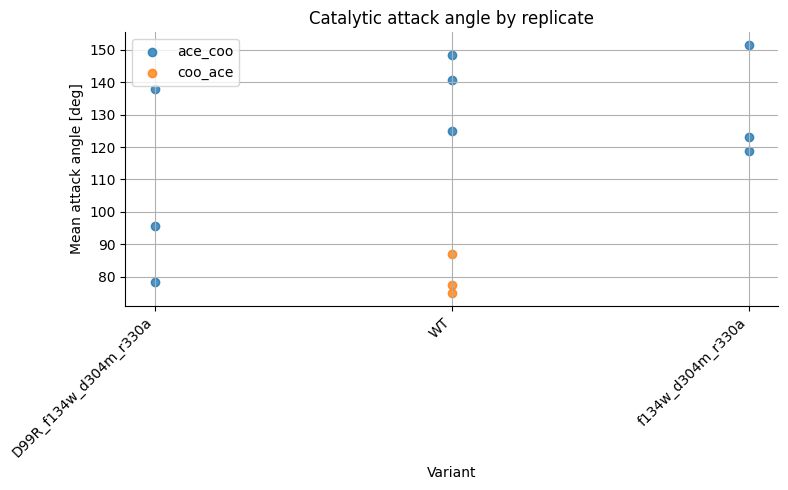

In [8]:
if not productive_geometry_replicate.empty:
    for col, ylabel, title in [
        ("attack_distance_A_mean", "Mean attack distance [Å]", "Catalytic attack distance by replicate"),
        ("attack_angle_og1_c_o_deg_mean", "Mean attack angle [deg]", "Catalytic attack angle by replicate"),
    ]:
        if col in productive_geometry_replicate.columns:
            plt.figure(figsize=(8, 5))
            for condition_name in sorted(productive_geometry_replicate["condition"].unique()):
                df_cond = productive_geometry_replicate[productive_geometry_replicate["condition"] == condition_name]
                plt.scatter(df_cond["variant"], df_cond[col], label=condition_name, alpha=0.8)
            plt.ylabel(ylabel)
            plt.xlabel("Variant")
            plt.title(title)
            plt.xticks(rotation=45, ha="right")
            plt.legend()
            plt.tight_layout()
            plt.show()


# 4. Substrate contact fingerprints

Residue-level contact frequencies highlight dominant protein-PA6 interactions.

In [9]:
if not substrate_contacts_variant.empty and require_columns(substrate_contacts_variant, ["condition", "variant", "resid", "resname", "contact_frequency_mean"], "substrate_contacts_variant"):
    TOP_N = 20
    top_contacts = (
        substrate_contacts_variant
        .groupby(["condition", "variant"], group_keys=False)
        .apply(lambda x: x.nlargest(TOP_N, "contact_frequency_mean"))
        .reset_index(drop=True)
    )
    display(top_contacts[[c for c in ["condition", "variant", "subunit_id", "resid", "resname", "contact_frequency_mean", "contact_frequency_sd", "n_replicates"] if c in top_contacts.columns]])


/w0/tmp/slurm_dwp46550.541736/ipykernel_199985/805441111.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  substrate_contacts_variant


,condition,variant,subunit_id,resid,resname,contact_frequency_mean,contact_frequency_sd,n_replicates
0,ace_coo,D99R_f134w_d304m_r330a,1,145,ILE,1.000000,0.000000,3
1,ace_coo,D99R_f134w_d304m_r330a,1,146,TYR,1.000000,0.000000,3
2,ace_coo,D99R_f134w_d304m_r330a,1,267,THR,1.000000,0.000000,3
3,ace_coo,D99R_f134w_d304m_r330a,2,139,LEU,1.000000,0.000000,3
4,ace_coo,D99R_f134w_d304m_r330a,2,98,TYR,0.999556,0.000769,3
...,...,...,...,...,...,...,...,...
75,coo_ace,WT,1,307,GLY,0.974257,0.037881,3
76,coo_ace,WT,3,330,ARG,0.969818,0.024274,3
77,coo_ace,WT,2,100,PHE,0.774523,0.065940,3
78,coo_ace,WT,3,331,LEU,0.727474,0.338429,3


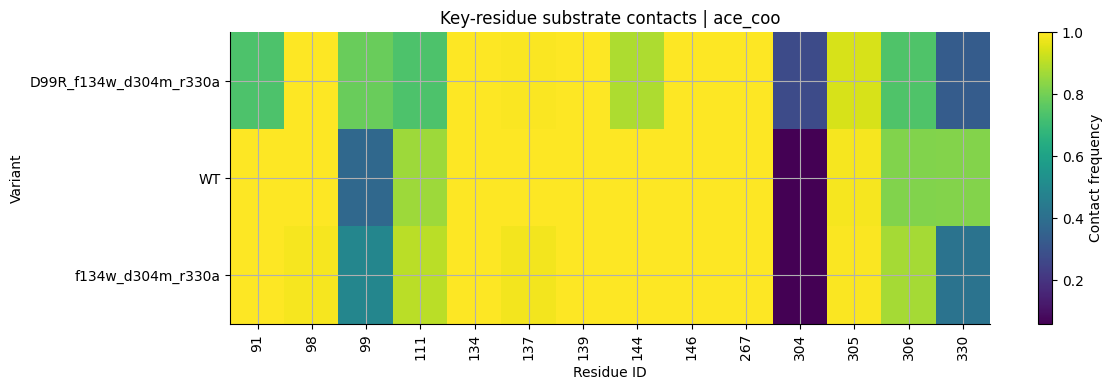

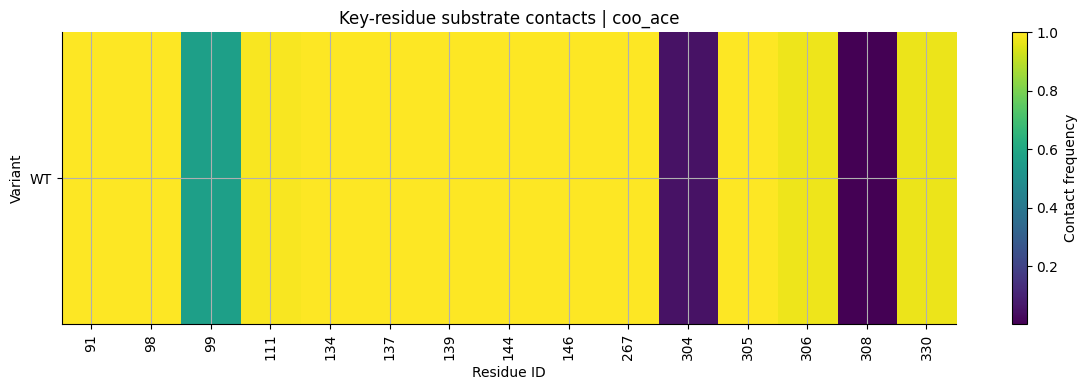

,condition,variant,substrate_resname,cutoff_A,subunit_id,resid,resname,contact_frequency_mean,contact_frequency_sd,n_replicates
33,ace_coo,D99R_f134w_d304m_r330a,UNL1,4.0,1,267,THR,1.000000,0.000000,3
17,ace_coo,D99R_f134w_d304m_r330a,UNL1,4.0,1,146,TYR,1.000000,0.000000,3
110,ace_coo,WT,UNL1,4.0,2,134,PHE,1.000000,0.000000,3
80,ace_coo,WT,UNL1,4.0,1,146,TYR,1.000000,0.000000,3
53,ace_coo,D99R_f134w_d304m_r330a,UNL1,4.0,2,139,LEU,1.000000,0.000000,3
233,coo_ace,WT,UNL1,4.0,2,134,PHE,1.000000,0.000000,3
176,ace_coo,f134w_d304m_r330a,UNL1,4.0,2,134,TRP,1.000000,0.000000,3
145,ace_coo,f134w_d304m_r330a,UNL1,4.0,1,146,TYR,1.000000,0.000000,3
114,ace_coo,WT,UNL1,4.0,2,139,LEU,1.000000,0.000000,3
196,coo_ace,WT,UNL1,4.0,1,91,ALA,1.000000,0.000000,3


In [10]:
important_residues = [91, 98, 99, 111, 134, 137, 139, 144, 146, 267, 304, 305, 306, 308, 330]

if not substrate_contacts_variant.empty and require_columns(substrate_contacts_variant, ["condition", "variant", "resid", "contact_frequency_mean"], "substrate_contacts_variant"):
    important_contacts = substrate_contacts_variant[substrate_contacts_variant["resid"].isin(important_residues)].copy()
    if not important_contacts.empty:
        compact = (important_contacts.groupby(["condition", "variant", "resid"], as_index=False).agg(contact_frequency_mean=("contact_frequency_mean", "max")))
        for condition_name in sorted(compact["condition"].unique()):
            heat_df = compact[compact["condition"] == condition_name].pivot_table(index="variant", columns="resid", values="contact_frequency_mean", fill_value=0.0)
            plt.figure(figsize=(12, 4))
            plt.imshow(heat_df.values, aspect="auto")
            plt.colorbar(label="Contact frequency")
            plt.yticks(range(len(heat_df.index)), heat_df.index)
            plt.xticks(range(len(heat_df.columns)), heat_df.columns, rotation=90)
            plt.xlabel("Residue ID")
            plt.ylabel("Variant")
            plt.title(f"Key-residue substrate contacts | {condition_name}")
            plt.tight_layout()
            plt.show()
        display(important_contacts.sort_values("contact_frequency_mean", ascending=False).head(30))
    else:
        print("No important residue contacts found.")


# 5. Pocket accessibility and substrate dynamics

Pocket-opening proxies and substrate shape descriptors are visualized if available.

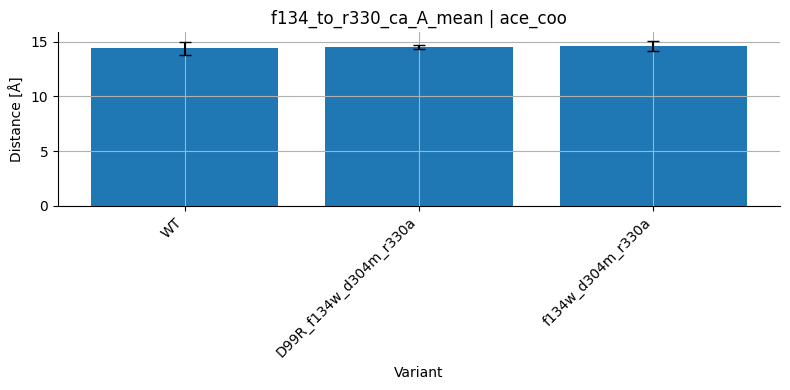

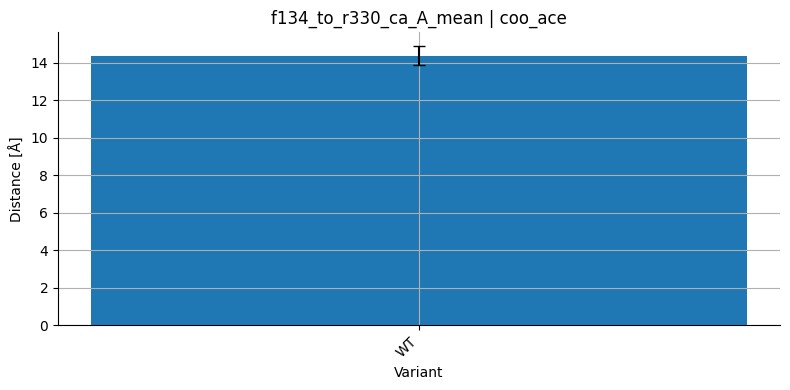

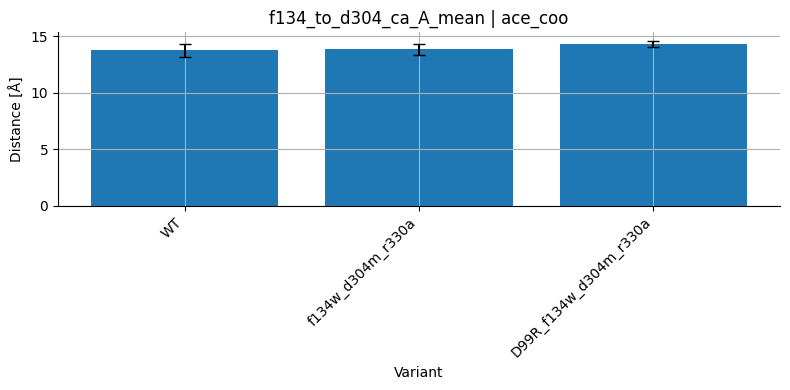

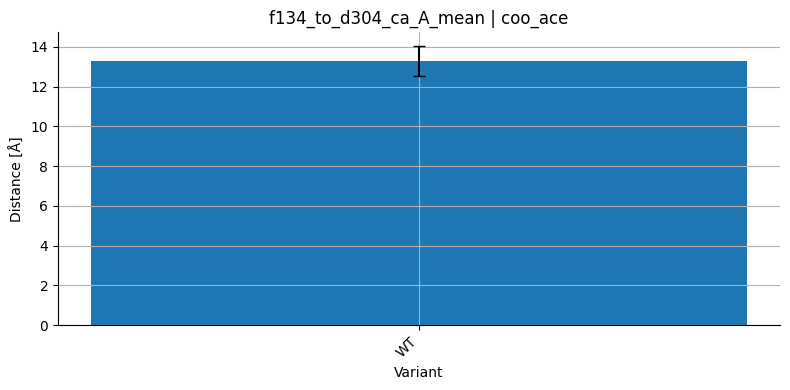

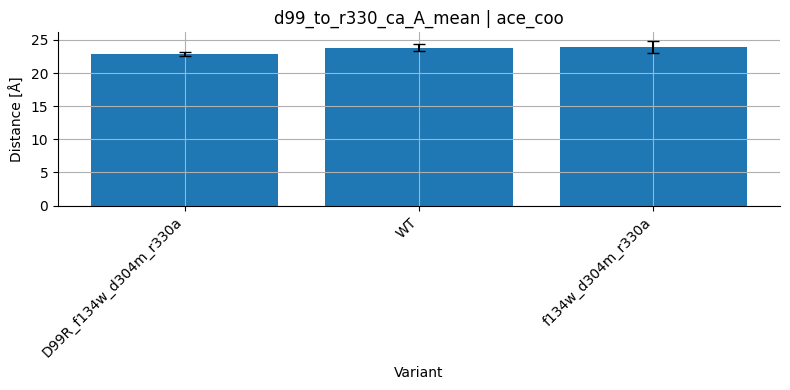

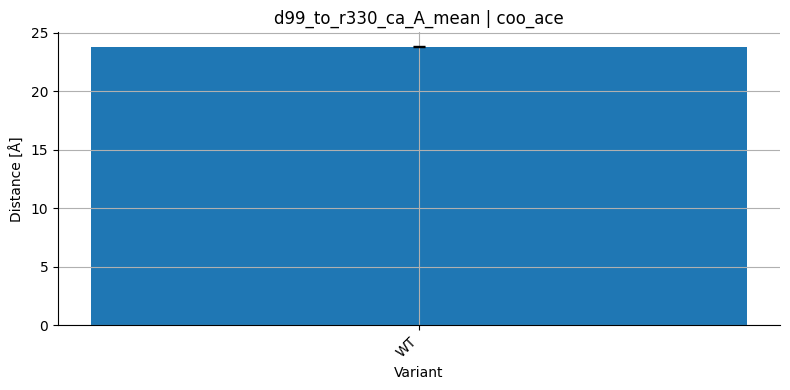

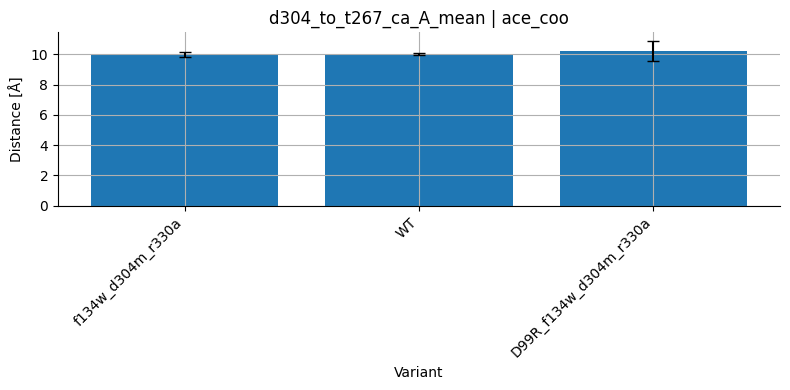

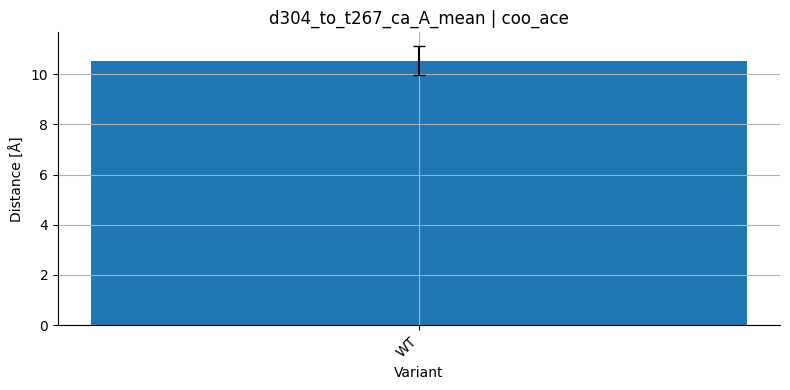

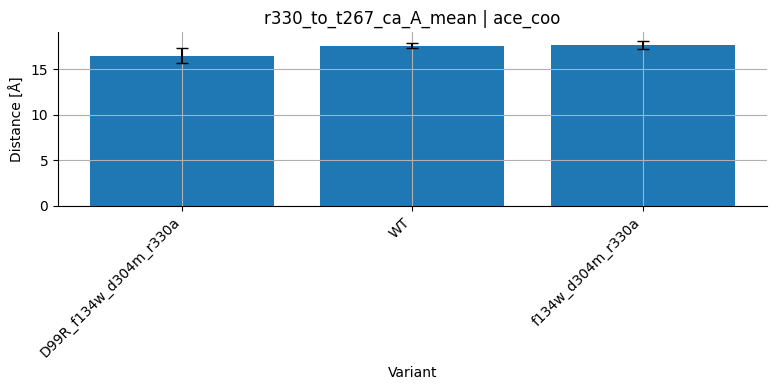

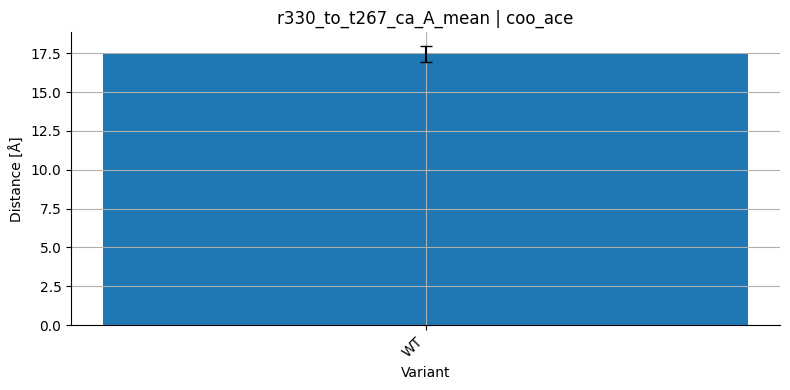

In [11]:
if not pocket_distance_replicate.empty:
    pocket_cols = [c for c in pocket_distance_replicate.columns if c.endswith("_mean") and ("_ca_A" in c or "distance" in c)]
    for col in pocket_cols:
        plot_df = pocket_distance_replicate.groupby(["condition", "variant"], as_index=False).agg(mean_value=(col, "mean"), sd_value=(col, "std"))
        for condition_name in sorted(plot_df["condition"].unique()):
            condition_df = plot_df[plot_df["condition"] == condition_name].sort_values("mean_value")
            plt.figure(figsize=(8, 4))
            plt.bar(condition_df["variant"], condition_df["mean_value"], yerr=condition_df["sd_value"], capsize=4)
            plt.ylabel("Distance [Å]")
            plt.xlabel("Variant")
            plt.title(f"{col} | {condition_name}")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()


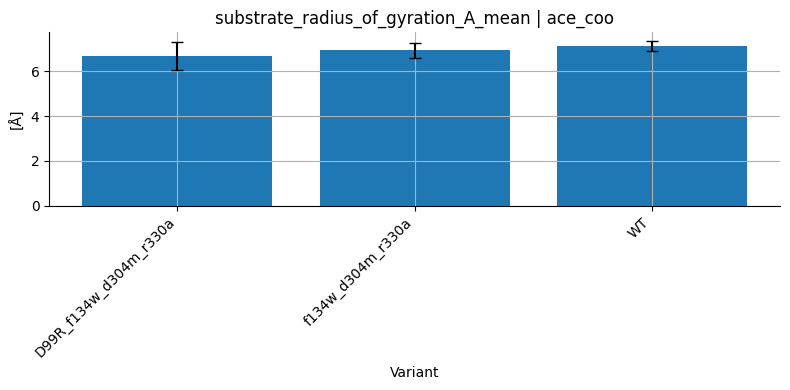

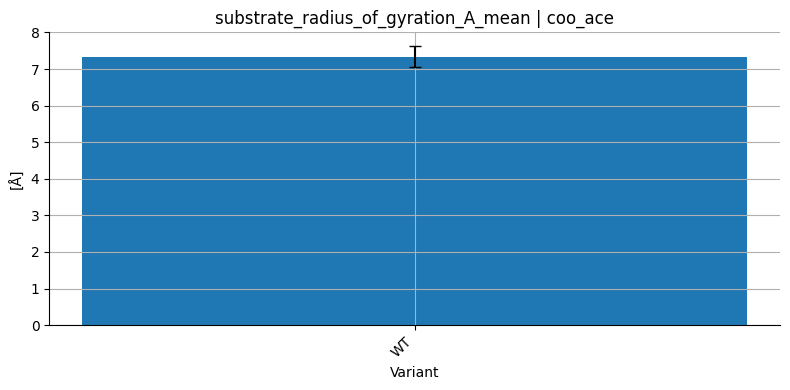

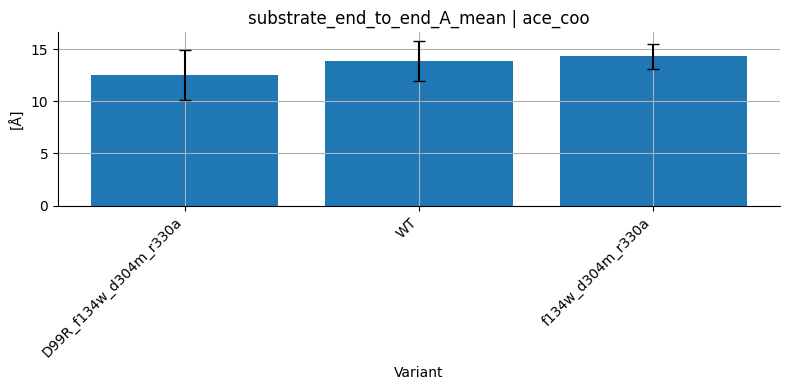

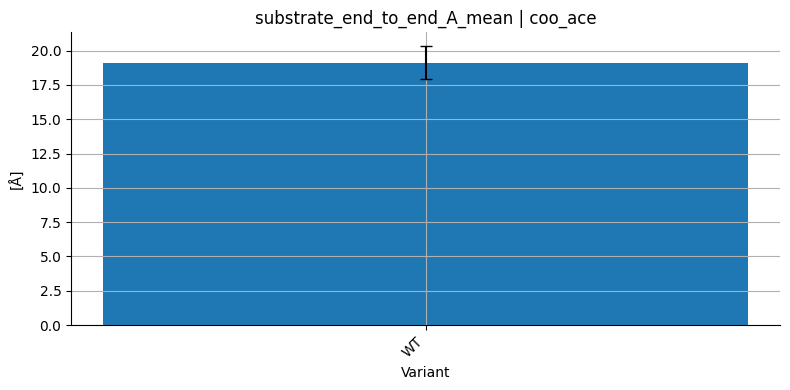

In [12]:
if not substrate_dynamics_replicate.empty:
    dynamic_cols = [c for c in ["substrate_radius_of_gyration_A_mean", "substrate_end_to_end_A_mean"] if c in substrate_dynamics_replicate.columns]
    for col in dynamic_cols:
        plot_df = substrate_dynamics_replicate.groupby(["condition", "variant"], as_index=False).agg(mean_value=(col, "mean"), sd_value=(col, "std"))
        for condition_name in sorted(plot_df["condition"].unique()):
            condition_df = plot_df[plot_df["condition"] == condition_name].sort_values("mean_value")
            plt.figure(figsize=(8, 4))
            plt.bar(condition_df["variant"], condition_df["mean_value"], yerr=condition_df["sd_value"], capsize=4)
            plt.ylabel("[Å]")
            plt.xlabel("Variant")
            plt.title(f"{col} | {condition_name}")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()


# 6. Feature robustness

Replicate robustness identifies which MD features are stable enough for scoring.

Most robust features:


,condition,variant,feature,mean_across_replicates,sd_between_replicates,cv_between_replicates,n_replicates
573,coo_ace,WT,polar_contacts_resid_306_max,1.000000,0.000000,0.000000,3
585,coo_ace,WT,contact_resid_134_maxfreq,1.000000,0.000000,0.000000,3
486,coo_ace,WT,productive_angle_max,1.000000,0.000000,0.000000,3
422,ace_coo,f134w_d304m_r330a,polar_contacts_resid_267_max,3.000000,0.000000,0.000000,3
151,ace_coo,WT,n_frames,751.000000,0.000000,0.000000,3
447,coo_ace,WT,n_frames,751.000000,0.000000,0.000000,3
142,ace_coo,D99R_f134w_d304m_r330a,contact_resid_267_maxfreq,1.000000,0.000000,0.000000,3
131,ace_coo,D99R_f134w_d304m_r330a,polar_contacts_resid_330_max,1.000000,0.000000,0.000000,3
189,ace_coo,WT,productive_distance_max,1.000000,0.000000,0.000000,3
427,ace_coo,f134w_d304m_r330a,polar_contacts_resid_330_max,1.000000,0.000000,0.000000,3


Most variable features:


,condition,variant,feature,mean_across_replicates,sd_between_replicates,cv_between_replicates,n_replicates
275,ace_coo,WT,polar_contacts_resid_304_max,0.333333,0.577350,1.732051,3
425,ace_coo,f134w_d304m_r330a,polar_contacts_resid_306_max,0.333333,0.577350,1.732051,3
332,ace_coo,f134w_d304m_r330a,productive_angle_min,0.333333,0.577350,1.732051,3
402,ace_coo,f134w_d304m_r330a,num_polar_contacts_min,0.333333,0.577350,1.732051,3
423,ace_coo,f134w_d304m_r330a,polar_contacts_resid_304_max,0.333333,0.577350,1.732051,3
184,ace_coo,WT,productive_angle_min,0.333333,0.577350,1.732051,3
391,ace_coo,f134w_d304m_r330a,polar_contacts_resid_306_sd,0.127709,0.221199,1.732051,3
374,ace_coo,f134w_d304m_r330a,polar_contacts_resid_306_mean,0.059476,0.103016,1.732051,3
389,ace_coo,f134w_d304m_r330a,polar_contacts_resid_304_sd,0.021040,0.036442,1.732051,3
372,ace_coo,f134w_d304m_r330a,polar_contacts_resid_304_mean,0.001332,0.002306,1.732051,3


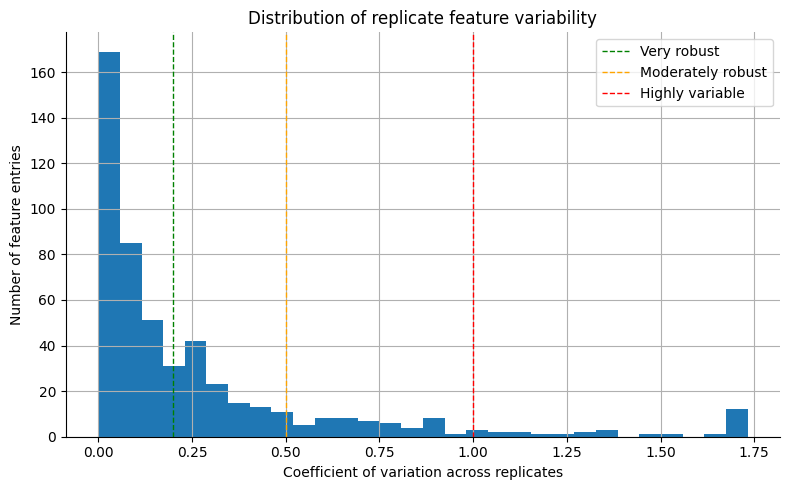

In [18]:
if not replicate_robustness.empty and require_columns(replicate_robustness, ["condition", "variant", "feature", "mean_across_replicates", "cv_between_replicates"], "replicate_robustness"):
    plot_df = replicate_robustness.copy()
    plot_df = plot_df[plot_df["mean_across_replicates"].abs() > 1e-3].copy()
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["cv_between_replicates"])

    print("Most robust features:")
    display(plot_df.sort_values("cv_between_replicates").head(30))

    print("Most variable features:")
    display(plot_df.sort_values("cv_between_replicates", ascending=False).head(30))

    plt.figure(figsize=(8, 5))
    plt.hist(plot_df["cv_between_replicates"], bins=30)
    plt.axvline(0.2, linestyle="--", linewidth=1, color="green", label="Very robust")
    plt.axvline(0.5, linestyle="--", linewidth=1, color="orange", label="Moderately robust")
    plt.axvline(1.0, linestyle="--", linewidth=1, color="red" ,label="Highly variable")
    plt.xlabel("Coefficient of variation across replicates")
    plt.ylabel("Number of feature entries")
    plt.title("Distribution of replicate feature variability")
    plt.legend()
    plt.tight_layout()
    plt.show()


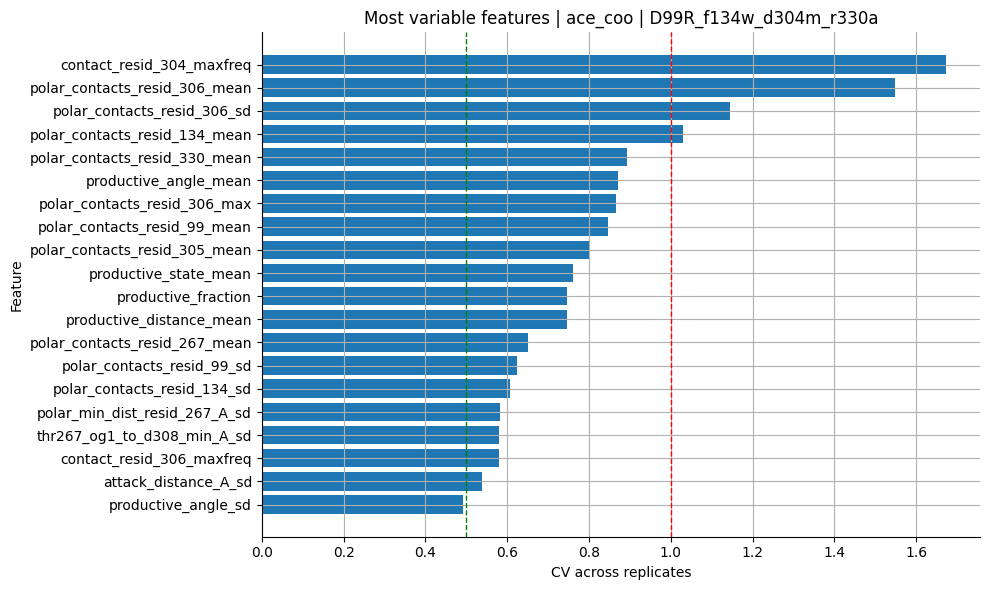

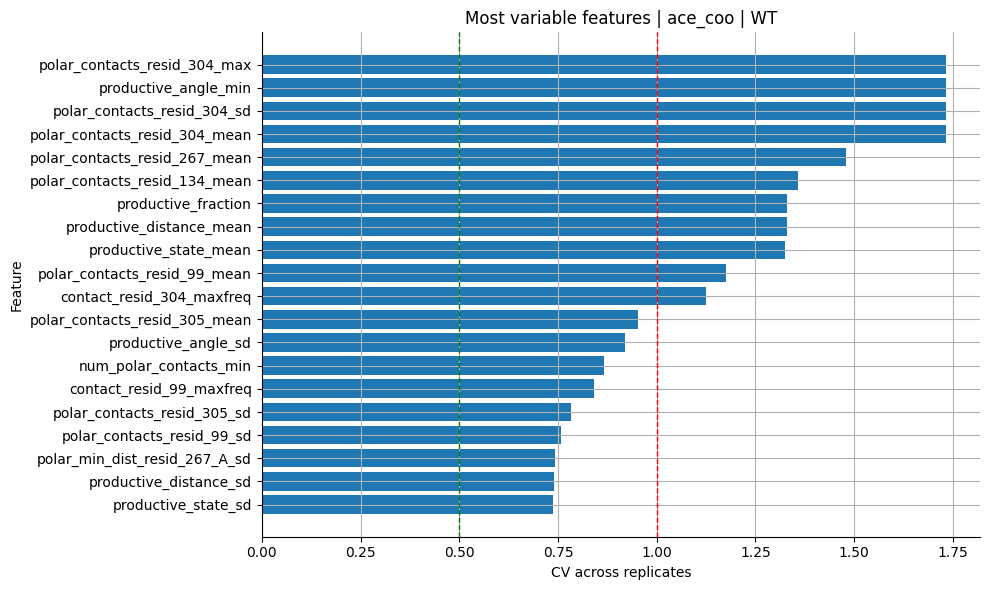

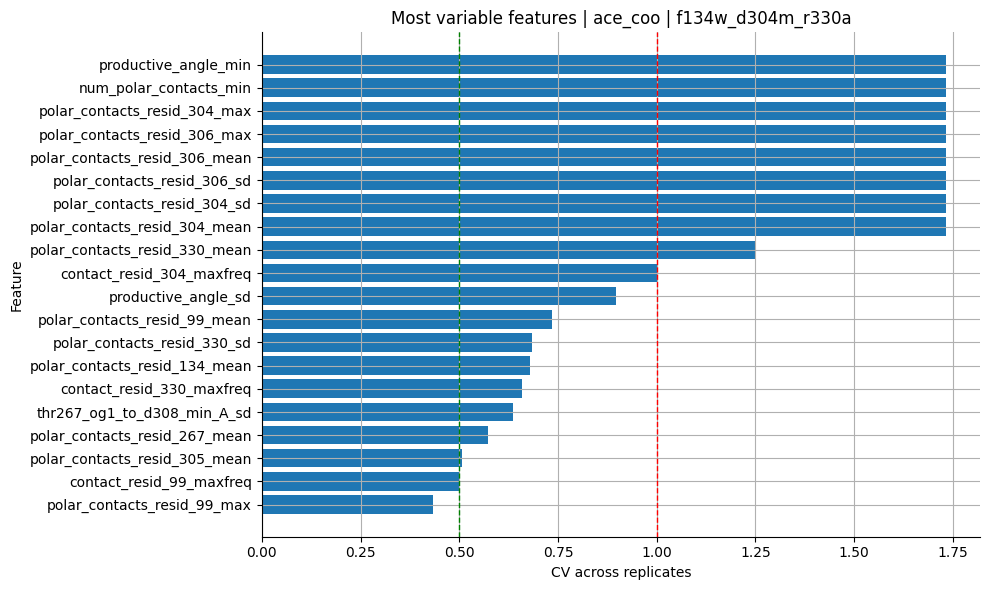

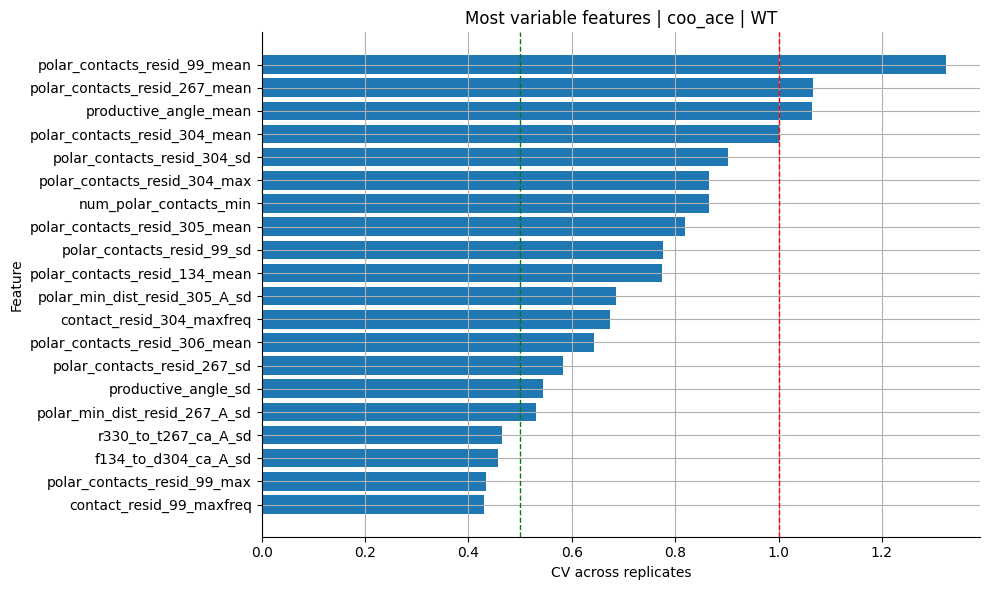

In [20]:
if not replicate_robustness.empty and require_columns(replicate_robustness, ["condition", "variant", "feature", "cv_between_replicates"], "replicate_robustness"):
    TOP_N = 20
    for (condition_name, variant), group in replicate_robustness.groupby(["condition", "variant"]):
        plot_df = group.copy().replace([np.inf, -np.inf], np.nan).dropna(subset=["cv_between_replicates"])
        plot_df = plot_df[plot_df["mean_across_replicates"].abs() > 1e-3] if "mean_across_replicates" in plot_df.columns else plot_df
        if plot_df.empty:
            continue
        plot_df = plot_df.nlargest(TOP_N, "cv_between_replicates").sort_values("cv_between_replicates")
        plt.figure(figsize=(10, 6))
        plt.barh(plot_df["feature"], plot_df["cv_between_replicates"])
        plt.axvline(0.5, linestyle="--", color="green", linewidth=1)
        plt.axvline(1.0, linestyle="--", color="red" ,linewidth=1)
        plt.xlabel("CV across replicates")
        plt.ylabel("Feature")
        plt.title(f"Most variable features | {condition_name} | {variant}")
        plt.tight_layout()
        plt.show()


# 7. Preliminary MD score

The preliminary MD score and its components are visualized if the score table is available.

,condition,variant,replicate,md_score_v01,score_productive_fraction,score_productive_geometry,score_productive_angle_legacy,score_attack_angle,score_attack_distance,score_triad_stability,score_thr_to_d306,score_thr_to_d308,score_substrate_pose_stability,score_substrate_rg,score_substrate_extendedness,score_f134_to_r330_ca_A,score_f134_to_d304_ca_A,score_d99_to_r330_ca_A,score_r330_to_t267_ca_A
0,ace_coo,D99R_f134w_d304m_r330a,1,0.425819,0.407769,0.350801,0.797404,0.888196,1.284336,0.936593,2.462500,-0.806580,1.452628,0.855217,-0.008557,-0.309341,1.437733,-1.309703,-2.051714
3,ace_coo,WT,1,0.326575,0.706338,0.700215,0.810929,0.417920,1.284664,-1.692316,0.988374,-0.523534,-1.540951,0.500630,0.058754,1.246108,1.087215,0.543220,0.311063
6,ace_coo,f134w_d304m_r330a,1,0.283857,0.026263,0.018025,0.817692,0.357764,-0.211257,-0.167872,-0.197100,-1.042840,-0.699114,0.331772,0.227970,1.774724,-0.654884,2.308843,1.367871
1,ace_coo,D99R_f134w_d304m_r330a,2,0.142828,2.497756,2.513843,-0.818819,-0.631581,0.974900,0.449263,-0.248864,-0.847164,0.299838,-2.072219,-0.878669,0.667397,0.517853,-0.543951,0.262834
8,ace_coo,f134w_d304m_r330a,3,0.075209,0.789274,0.800048,0.780498,0.200337,0.660189,-1.094737,0.437135,-0.469876,0.640636,-1.169058,-0.564925,-0.359502,0.949829,-0.497555,0.025839
9,coo_ace,WT,1,0.048958,-0.985556,-0.980302,-1.630311,-1.374415,-1.810324,1.149214,0.391363,1.456632,1.291549,1.082615,1.230207,1.004437,0.203015,0.348649,-0.642398
7,ace_coo,f134w_d304m_r330a,2,0.008756,0.374594,0.384079,0.858266,1.374436,0.163566,-1.659824,-0.803490,0.640459,-0.749867,0.188194,-0.331109,-0.356267,-0.052301,-0.132896,0.233494
4,ace_coo,WT,2,-0.010433,-0.753335,-0.747359,0.837979,0.984446,-0.048149,-0.422664,0.317668,-0.879569,-1.480388,0.751044,-0.014947,-0.076285,-0.551970,0.970668,0.956367
11,coo_ace,WT,3,-0.182931,-0.985556,-0.980302,-1.356433,-1.288754,-0.982201,0.713164,-0.330303,-1.066897,0.417345,1.263442,1.929776,-0.382873,-0.630607,0.304020,0.632210
5,ace_coo,WT,3,-0.185143,-0.902620,-0.897108,0.858266,1.266388,0.251270,0.803202,-0.489207,0.644905,0.248024,-0.360133,-1.142859,-1.753371,-0.722697,-0.636102,0.054901


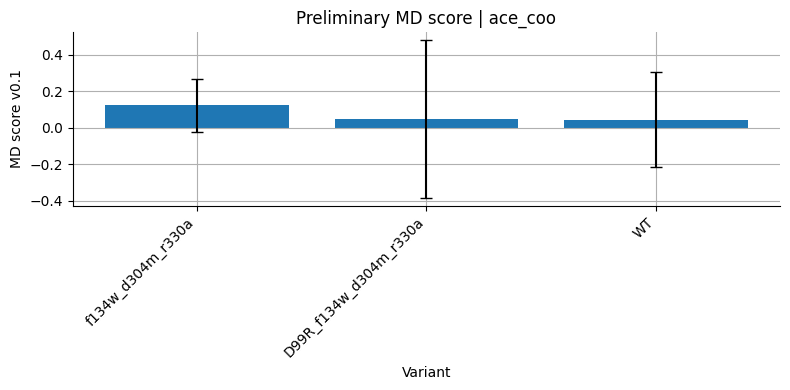

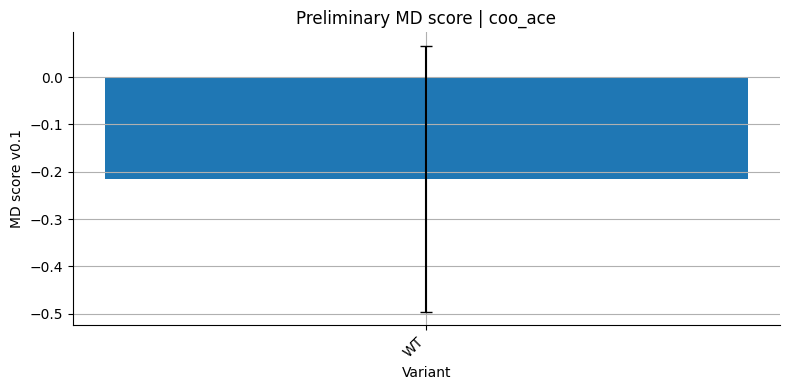

In [15]:
if not score_df.empty and "md_score_v01" in score_df.columns:
    rank_cols = ["condition", "variant", "replicate", "md_score_v01"]
    score_component_cols = [c for c in score_df.columns if c.startswith("score_")]
    display(score_df[rank_cols + score_component_cols].sort_values("md_score_v01", ascending=False))

    plot_df = score_df.groupby(["condition", "variant"], as_index=False).agg(md_score_mean=("md_score_v01", "mean"), md_score_sd=("md_score_v01", "std"), n_replicates=("replicate", "count"))
    for condition_name in sorted(plot_df["condition"].unique()):
        condition_df = plot_df[plot_df["condition"] == condition_name].copy().sort_values("md_score_mean", ascending=False)
        plt.figure(figsize=(8, 4))
        plt.bar(condition_df["variant"], condition_df["md_score_mean"], yerr=condition_df["md_score_sd"], capsize=4)
        plt.ylabel("MD score v0.1")
        plt.xlabel("Variant")
        plt.title(f"Preliminary MD score | {condition_name}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
else:
    print("No MD score table found.")


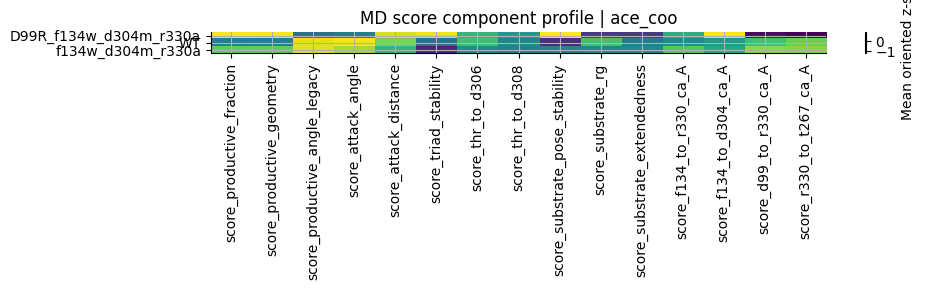

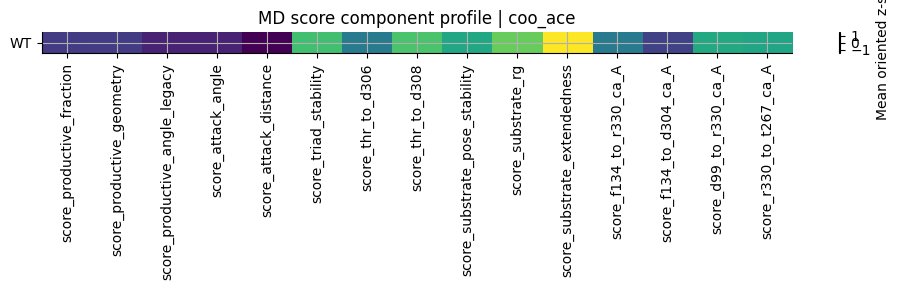

In [16]:
if not score_df.empty and "md_score_v01" in score_df.columns:
    score_component_cols = [c for c in score_df.columns if c.startswith("score_")]
    if score_component_cols:
        component_summary = score_df.groupby(["condition", "variant"], as_index=False)[score_component_cols].mean()
        for condition_name in sorted(component_summary["condition"].unique()):
            condition_df = component_summary[component_summary["condition"] == condition_name].copy()
            heat_df = condition_df.set_index("variant")[score_component_cols]
            plt.figure(figsize=(max(10, len(score_component_cols) * 0.55), max(3, len(heat_df) * 0.6)))
            plt.imshow(heat_df.values, aspect="auto")
            plt.colorbar(label="Mean oriented z-score")
            plt.yticks(range(len(heat_df.index)), heat_df.index)
            plt.xticks(range(len(heat_df.columns)), heat_df.columns, rotation=90)
            plt.title(f"MD score component profile | {condition_name}")
            plt.tight_layout()
            plt.show()



Very robust and robust features:


,condition,variant,feature,mean_across_replicates,sd_between_replicates,cv_between_replicates,robustness_category
572,coo_ace,WT,polar_contacts_resid_305_max,2.000000,0.000000,0.000000,Very robust
573,coo_ace,WT,polar_contacts_resid_306_max,1.000000,0.000000,0.000000,Very robust
131,ace_coo,D99R_f134w_d304m_r330a,polar_contacts_resid_330_max,1.000000,0.000000,0.000000,Very robust
142,ace_coo,D99R_f134w_d304m_r330a,contact_resid_267_maxfreq,1.000000,0.000000,0.000000,Very robust
190,ace_coo,WT,productive_angle_max,1.000000,0.000000,0.000000,Very robust
...,...,...,...,...,...,...,...
174,ace_coo,WT,attack_distance_A_sd,0.887291,0.423901,0.477747,Robust
98,ace_coo,D99R_f134w_d304m_r330a,polar_min_dist_resid_99_A_sd,0.842786,0.413357,0.490465,Robust
30,ace_coo,D99R_f134w_d304m_r330a,productive_angle_sd,0.331603,0.163458,0.492934,Robust
240,ace_coo,WT,polar_contacts_resid_267_sd,0.305784,0.151774,0.496344,Robust



Robustness category summary:


,category,n_features
0,Very robust,321
1,Robust,116
2,Highly variable,79


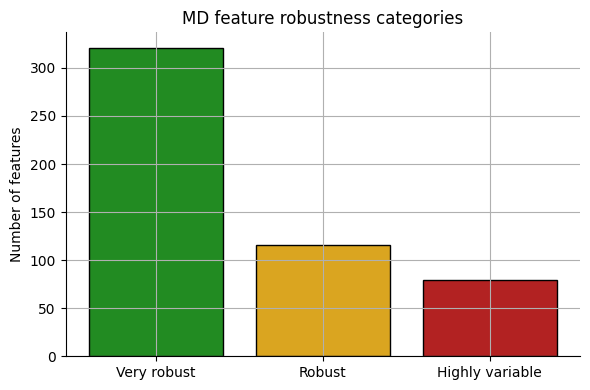

In [21]:
# ============================================================
# Identify robust MD features
# ============================================================

ROBUST_THRESHOLD = 0.5
VERY_ROBUST_THRESHOLD = 0.2

if not replicate_robustness.empty and require_columns(
    replicate_robustness,
    [
        "condition",
        "variant",
        "feature",
        "mean_across_replicates",
        "cv_between_replicates",
    ],
    "replicate_robustness",
):

    robust_df = replicate_robustness.copy()

    # Remove unstable CV cases caused by near-zero means
    robust_df = robust_df[
        robust_df["mean_across_replicates"].abs() > 1e-3
    ].copy()

    robust_df = robust_df.replace([np.inf, -np.inf], np.nan)
    robust_df = robust_df.dropna(subset=["cv_between_replicates"])

    # --------------------------------------------------------
    # Categorize robustness
    # --------------------------------------------------------

    robust_df["robustness_category"] = "Highly variable"

    robust_df.loc[
        robust_df["cv_between_replicates"] < ROBUST_THRESHOLD,
        "robustness_category"
    ] = "Robust"

    robust_df.loc[
        robust_df["cv_between_replicates"] < VERY_ROBUST_THRESHOLD,
        "robustness_category"
    ] = "Very robust"

    # --------------------------------------------------------
    # Show robust features
    # --------------------------------------------------------

    robust_features = robust_df[
        robust_df["cv_between_replicates"] < ROBUST_THRESHOLD
    ].copy()

    robust_features = robust_features.sort_values(
        "cv_between_replicates"
    )

    print("\nVery robust and robust features:")
    display(
        robust_features[
            [
                "condition",
                "variant",
                "feature",
                "mean_across_replicates",
                "sd_between_replicates",
                "cv_between_replicates",
                "robustness_category",
            ]
        ]
    )

    # --------------------------------------------------------
    # Summary counts
    # --------------------------------------------------------

    summary_counts = (
        robust_df["robustness_category"]
        .value_counts()
        .rename_axis("category")
        .reset_index(name="n_features")
    )

    print("\nRobustness category summary:")
    display(summary_counts)

    # --------------------------------------------------------
    # Robustness category plot
    # --------------------------------------------------------

    plt.figure(figsize=(6, 4))

    category_order = [
        "Very robust",
        "Robust",
        "Highly variable",
    ]

    counts = [
        summary_counts.loc[
            summary_counts["category"] == cat,
            "n_features"
        ].sum()
        for cat in category_order
    ]

    plt.bar(
        category_order,
        counts,
        color=[
            "forestgreen",
            "goldenrod",
            "firebrick",
        ],
        edgecolor="black",
    )

    plt.ylabel("Number of features")
    plt.title("MD feature robustness categories")

    plt.tight_layout()
    plt.show()

,feature_family,mean_cv,median_cv,sd_cv,n_features
1,pocket_opening,0.077655,0.040188,0.102142,96
5,substrate_dynamics,0.127995,0.088379,0.098262,44
0,other,0.140006,0.096093,0.138699,140
6,triad_stability,0.207193,0.175616,0.156607,44
4,substrate_contacts,0.311790,0.073397,0.430981,28
3,productive_geometry,0.349078,0.172535,0.427264,67
2,polar_contacts,0.637086,0.476161,0.515999,97


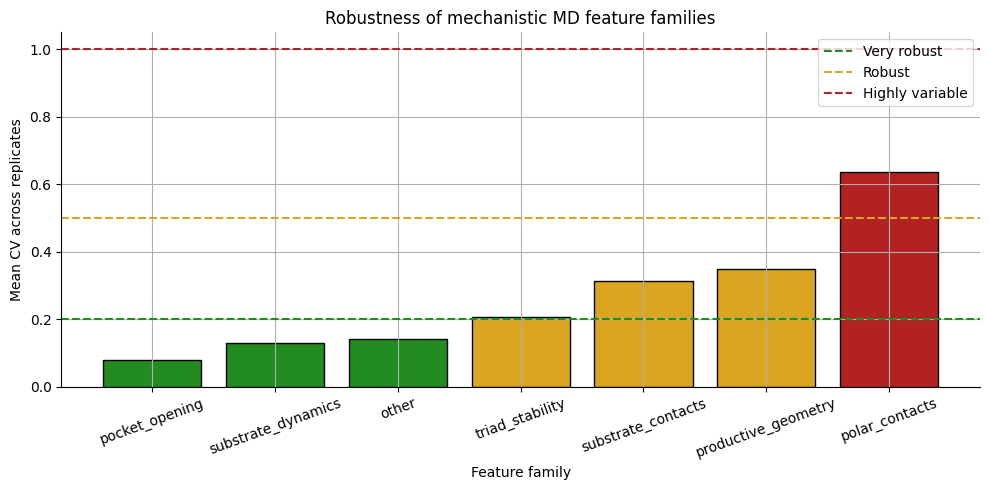

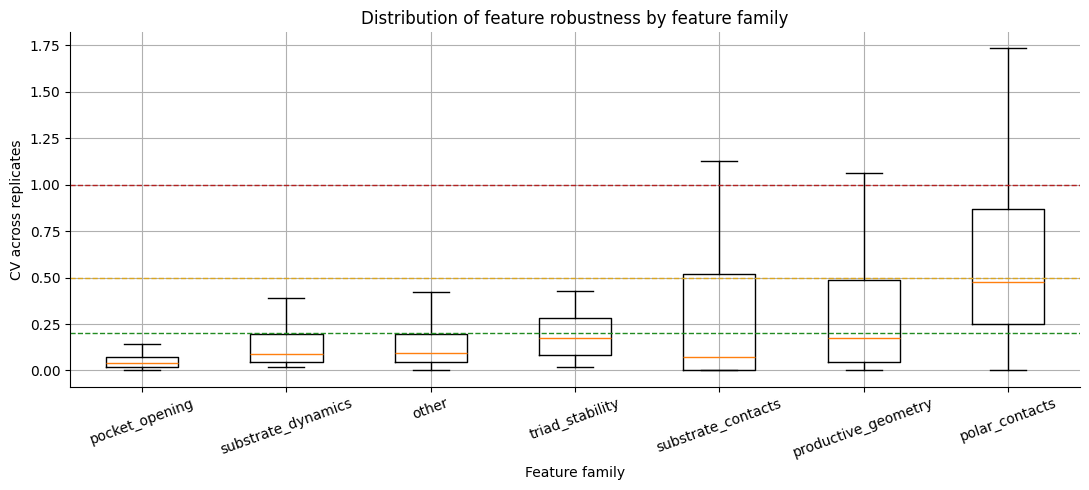

In [22]:
# ============================================================
# Group feature types by robustness
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if not replicate_robustness.empty:

    feature_type_df = replicate_robustness.copy()

    # --------------------------------------------------------
    # Remove unstable CV artefacts close to zero
    # --------------------------------------------------------

    feature_type_df = feature_type_df.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    feature_type_df = feature_type_df.dropna(
        subset=["cv_between_replicates"]
    )

    if "mean_across_replicates" in feature_type_df.columns:
        feature_type_df = feature_type_df[
            feature_type_df["mean_across_replicates"].abs() > 1e-3
        ]

    # --------------------------------------------------------
    # Assign feature families
    # --------------------------------------------------------

    def classify_feature(feature_name):

        feature_name = str(feature_name).lower()

        if "productive" in feature_name or "attack_" in feature_name:
            return "productive_geometry"

        elif "triad" in feature_name or "thr267" in feature_name:
            return "triad_stability"

        elif "substrate_" in feature_name:
            return "substrate_dynamics"

        elif "polar_contacts" in feature_name:
            return "polar_contacts"

        elif "contact_resid" in feature_name:
            return "substrate_contacts"

        elif "_to_" in feature_name:
            return "pocket_opening"

        elif "rmsd" in feature_name:
            return "global_rmsd"

        elif "rmsf" in feature_name:
            return "local_flexibility"

        else:
            return "other"

    feature_type_df["feature_family"] = feature_type_df["feature"].apply(
        classify_feature
    )

    # --------------------------------------------------------
    # Aggregate robustness statistics
    # --------------------------------------------------------

    family_summary = (
        feature_type_df
        .groupby("feature_family", as_index=False)
        .agg(
            mean_cv=("cv_between_replicates", "mean"),
            median_cv=("cv_between_replicates", "median"),
            sd_cv=("cv_between_replicates", "std"),
            n_features=("feature", "count"),
        )
        .sort_values("mean_cv")
    )

    display(family_summary)

    # --------------------------------------------------------
    # Plot mean robustness by feature family
    # --------------------------------------------------------

    plt.figure(figsize=(10, 5))

    colors = []

    for cv in family_summary["mean_cv"]:

        if cv < 0.2:
            colors.append("forestgreen")

        elif cv < 0.5:
            colors.append("goldenrod")

        else:
            colors.append("firebrick")

    plt.bar(
        family_summary["feature_family"],
        family_summary["mean_cv"],
        color=colors,
        edgecolor="black",
    )

    plt.axhline(
        0.2,
        linestyle="--",
        color="forestgreen",
        linewidth=1.5,
        label="Very robust",
    )

    plt.axhline(
        0.5,
        linestyle="--",
        color="goldenrod",
        linewidth=1.5,
        label="Robust",
    )

    plt.axhline(
        1.0,
        linestyle="--",
        color="firebrick",
        linewidth=1.5,
        label="Highly variable",
    )

    plt.ylabel("Mean CV across replicates")
    plt.xlabel("Feature family")

    plt.title("Robustness of mechanistic MD feature families")

    plt.xticks(rotation=20)

    plt.legend()

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Distribution of CVs per feature family
    # --------------------------------------------------------

    families = family_summary["feature_family"].tolist()

    data = [
        feature_type_df.loc[
            feature_type_df["feature_family"] == fam,
            "cv_between_replicates"
        ].values
        for fam in families
    ]

    plt.figure(figsize=(11, 5))

    plt.boxplot(
        data,
        tick_labels=families,
        showfliers=False,
    )

    plt.axhline(
        0.2,
        linestyle="--",
        color="forestgreen",
        linewidth=1,
    )

    plt.axhline(
        0.5,
        linestyle="--",
        color="goldenrod",
        linewidth=1,
    )

    plt.axhline(
        1.0,
        linestyle="--",
        color="firebrick",
        linewidth=1,
    )

    plt.ylabel("CV across replicates")
    plt.xlabel("Feature family")

    plt.title("Distribution of feature robustness by feature family")

    plt.xticks(rotation=20)

    plt.tight_layout()
    plt.show()


VERY ROBUST FEATURES


,feature,mean_cv,median_cv,max_cv,n_entries,robustness
95,productive_angle_max,0.000000,0.000000,0.000000,4,Very robust
99,productive_distance_max,0.000000,0.000000,0.000000,3,Very robust
37,n_frames,0.000000,0.000000,0.000000,4,Very robust
103,productive_state_max,0.000000,0.000000,0.000000,3,Very robust
8,contact_resid_134_maxfreq,0.000192,0.000000,0.000769,4,Very robust
...,...,...,...,...,...,...
117,substrate_radius_of_gyration_A_sd,0.184844,0.191429,0.326360,4,Very robust
45,polar_contacts_resid_267_max,0.186859,0.123718,0.500000,4,Very robust
92,polar_min_dist_resid_99_A_mean,0.193982,0.176462,0.381284,4,Very robust
2,attack_angle_og1_c_o_deg_min,0.195925,0.140311,0.449440,4,Very robust



ROBUST FEATURES


,feature,mean_cv,median_cv,max_cv,n_entries,robustness
68,polar_min_dist_resid_267_A_mean,0.210719,0.200586,0.265777,4,Robust
120,substrate_rmsd_A_sd,0.212011,0.224405,0.351757,4,Robust
94,polar_min_dist_resid_99_A_sd,0.212358,0.168107,0.490465,4,Robust
13,contact_resid_330_maxfreq,0.230792,0.119302,0.659534,4,Robust
3,attack_angle_og1_c_o_deg_sd,0.233431,0.222918,0.374001,4,Robust
66,polar_min_dist_resid_134_A_sd,0.235573,0.254807,0.320141,4,Robust
126,thr267_og1_to_d308_min_A_mean,0.236212,0.220372,0.346082,4,Robust
131,triad_rmsd_A_sd,0.241193,0.230621,0.354894,4,Robust
12,contact_resid_306_maxfreq,0.251580,0.191993,0.579800,4,Robust
42,polar_contacts_resid_134_max,0.253445,0.290385,0.433013,4,Robust



HIGHLY VARIABLE FEATURES


,feature,mean_cv,median_cv,max_cv,n_entries,robustness
97,productive_angle_min,1.732051,1.732051,1.732051,2,Highly variable
49,polar_contacts_resid_304_mean,1.488034,1.732051,1.732051,3,Highly variable
50,polar_contacts_resid_304_sd,1.455714,1.732051,1.732051,3,Highly variable
48,polar_contacts_resid_304_max,1.443376,1.732051,1.732051,3,Highly variable
55,polar_contacts_resid_306_mean,1.147811,1.108163,1.732051,4,Highly variable
10,contact_resid_304_maxfreq,1.118352,1.063819,1.672549,4,Highly variable
61,polar_contacts_resid_99_mean,1.019969,1.011224,1.323628,4,Highly variable
43,polar_contacts_resid_134_mean,0.959670,0.901640,1.356696,4,Highly variable
40,num_polar_contacts_min,0.952628,0.866025,1.732051,4,Highly variable
46,polar_contacts_resid_267_mean,0.942981,0.858933,1.480009,4,Highly variable


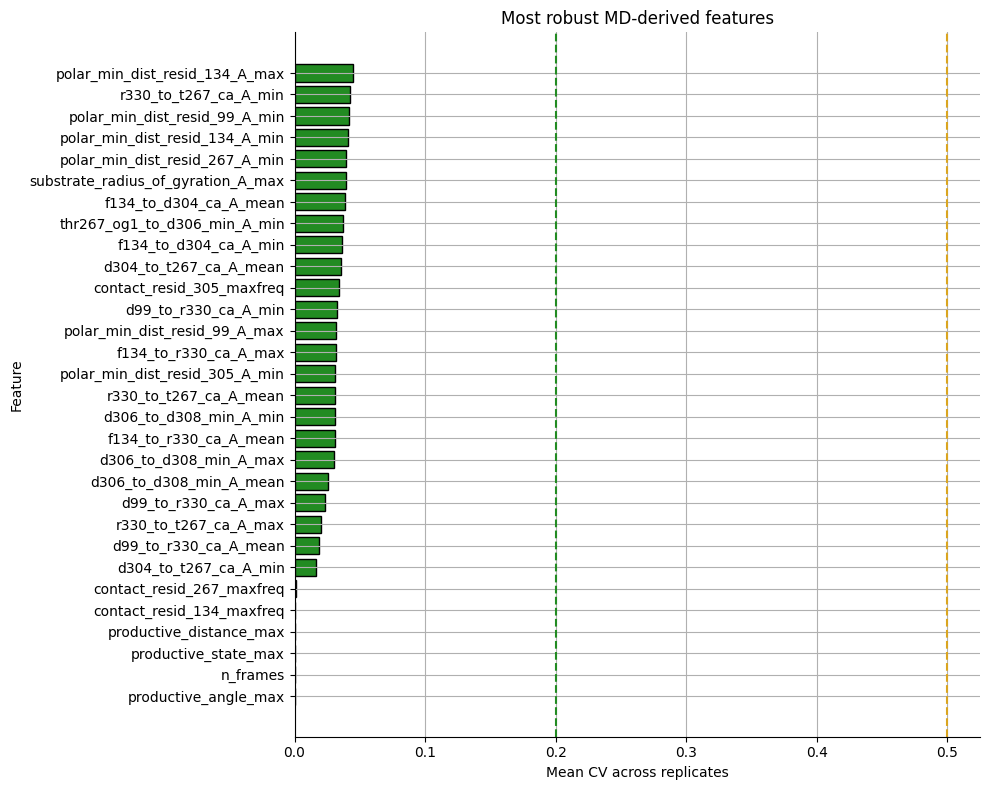

In [23]:
# ============================================================
# Show exactly which MD features are robust
# ============================================================

ROBUST_THRESHOLD = 0.5
VERY_ROBUST_THRESHOLD = 0.2

if not replicate_robustness.empty:

    robust_df = replicate_robustness.copy()

    # --------------------------------------------------------
    # Clean dataframe
    # --------------------------------------------------------

    robust_df = robust_df.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    robust_df = robust_df.dropna(
        subset=["cv_between_replicates"]
    )

    if "mean_across_replicates" in robust_df.columns:
        robust_df = robust_df[
            robust_df["mean_across_replicates"].abs() > 1e-3
        ]

    # --------------------------------------------------------
    # Categorize robustness
    # --------------------------------------------------------

    robust_df["robustness"] = "Highly variable"

    robust_df.loc[
        robust_df["cv_between_replicates"] < ROBUST_THRESHOLD,
        "robustness"
    ] = "Robust"

    robust_df.loc[
        robust_df["cv_between_replicates"] < VERY_ROBUST_THRESHOLD,
        "robustness"
    ] = "Very robust"

    # --------------------------------------------------------
    # Group by feature name
    # --------------------------------------------------------

    feature_summary = (
        robust_df
        .groupby("feature", as_index=False)
        .agg(
            mean_cv=("cv_between_replicates", "mean"),
            median_cv=("cv_between_replicates", "median"),
            max_cv=("cv_between_replicates", "max"),
            n_entries=("cv_between_replicates", "count"),
        )
        .sort_values("mean_cv")
    )

    # --------------------------------------------------------
    # Assign robustness category
    # --------------------------------------------------------

    feature_summary["robustness"] = "Highly variable"

    feature_summary.loc[
        feature_summary["mean_cv"] < ROBUST_THRESHOLD,
        "robustness"
    ] = "Robust"

    feature_summary.loc[
        feature_summary["mean_cv"] < VERY_ROBUST_THRESHOLD,
        "robustness"
    ] = "Very robust"

    # --------------------------------------------------------
    # Show robust features
    # --------------------------------------------------------

    print("\n==============================")
    print("VERY ROBUST FEATURES")
    print("==============================")

    display(
        feature_summary[
            feature_summary["robustness"] == "Very robust"
        ]
        .sort_values("mean_cv")
    )

    print("\n==============================")
    print("ROBUST FEATURES")
    print("==============================")

    display(
        feature_summary[
            feature_summary["robustness"] == "Robust"
        ]
        .sort_values("mean_cv")
    )

    print("\n==============================")
    print("HIGHLY VARIABLE FEATURES")
    print("==============================")

    display(
        feature_summary[
            feature_summary["robustness"] == "Highly variable"
        ]
        .sort_values("mean_cv", ascending=False)
    )

    # --------------------------------------------------------
    # Plot top most robust features
    # --------------------------------------------------------

    top_robust = (
        feature_summary
        .sort_values("mean_cv")
        .head(30)
    )

    plt.figure(figsize=(10, 8))

    colors = []

    for cat in top_robust["robustness"]:

        if cat == "Very robust":
            colors.append("forestgreen")

        elif cat == "Robust":
            colors.append("goldenrod")

        else:
            colors.append("firebrick")

    plt.barh(
        top_robust["feature"],
        top_robust["mean_cv"],
        color=colors,
        edgecolor="black",
    )

    plt.axvline(
        VERY_ROBUST_THRESHOLD,
        linestyle="--",
        color="forestgreen",
        linewidth=1.5,
    )

    plt.axvline(
        ROBUST_THRESHOLD,
        linestyle="--",
        color="goldenrod",
        linewidth=1.5,
    )

    plt.xlabel("Mean CV across replicates")
    plt.ylabel("Feature")

    plt.title("Most robust MD-derived features")

    plt.tight_layout()
    plt.show()

Explained variance:
PC1: 0.271
PC2: 0.148


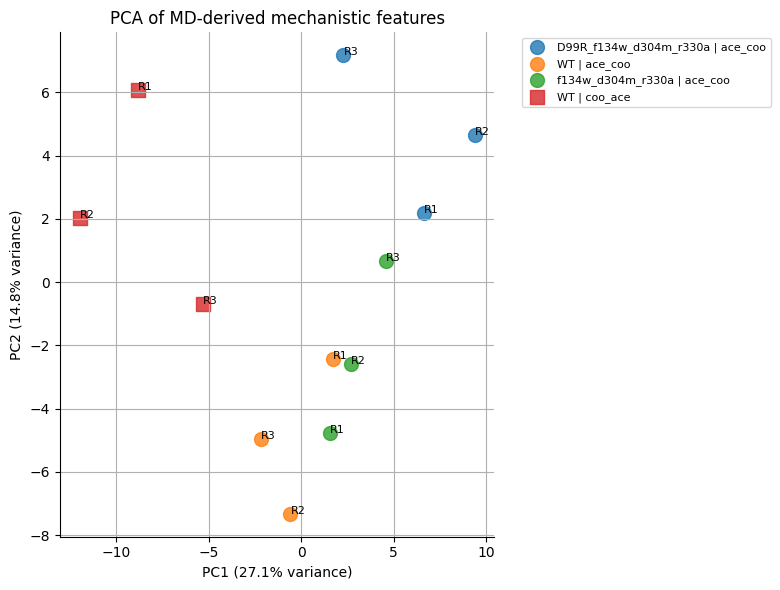


Top PC1-driving features:


,PC1_loading,PC2_loading,abs_PC1,abs_PC2
productive_distance_sd,0.155972,0.012112,0.155972,0.012112
productive_state_sd,0.155772,0.012117,0.155772,0.012117
polar_min_dist_resid_330_A_mean,0.154082,0.013053,0.154082,0.013053
mean_distance_A,-0.151334,0.035823,0.151334,0.035823
attack_distance_A_mean,-0.151334,0.035823,0.151334,0.035823
polar_contacts_resid_330_max,-0.150982,0.026206,0.150982,0.026206
attack_distance_A_min,-0.149426,0.080153,0.149426,0.080153
min_distance_A,-0.149426,0.080153,0.149426,0.080153
polar_contacts_resid_330_sd,-0.149020,0.039269,0.149020,0.039269
polar_contacts_resid_330_mean,-0.148968,0.076205,0.148968,0.076205



Top PC2-driving features:


,PC1_loading,PC2_loading,abs_PC1,abs_PC2
r330_to_t267_ca_A_sd,0.024168,0.189957,0.024168,0.189957
r330_to_t267_ca_A_min,-0.060836,-0.187905,0.060836,0.187905
substrate_rmsd_A_max,-0.005118,-0.181130,0.005118,0.181130
attack_angle_og1_c_o_deg_min,0.021035,-0.172138,0.021035,0.172138
productive_angle_mean,0.072084,-0.169093,0.072084,0.169093
attack_angle_og1_c_o_deg_mean,0.070230,-0.166905,0.070230,0.166905
substrate_rmsd_A_mean,-0.022352,-0.157460,0.022352,0.157460
d304_to_t267_ca_A_max,-0.049017,0.155291,0.049017,0.155291
thr267_og1_to_d306_min_A_max,-0.026099,0.152785,0.026099,0.152785
substrate_radius_of_gyration_A_max,0.012911,-0.150615,0.012911,0.150615


In [25]:
# ============================================================
# PCA of MD-derived feature space
# ============================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Prepare feature matrix
# ------------------------------------------------------------

pca_df = md_filter_features_replicate.copy()

# Keep metadata separately
metadata_cols = ["condition", "variant", "replicate"]

metadata = pca_df[metadata_cols].copy()

# Select only numeric columns
feature_cols = [
    c for c in pca_df.select_dtypes(include=[np.number, bool]).columns
    if c not in ["replicate"]
]

X = pca_df[feature_cols].copy()

# ------------------------------------------------------------
# Remove problematic features
# ------------------------------------------------------------

# Remove columns with NaNs only
X = X.dropna(axis=1, how="all")

# Fill remaining NaNs with column means
X = X.fillna(X.mean())

# Remove zero-variance features
stds = X.std(axis=0)

X = X.loc[:, stds > 1e-12]

# ------------------------------------------------------------
# Standardize features
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# PCA
# ------------------------------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# ------------------------------------------------------------
# Build PCA dataframe
# ------------------------------------------------------------

pca_results = metadata.copy()

pca_results["PC1"] = X_pca[:, 0]
pca_results["PC2"] = X_pca[:, 1]

# ------------------------------------------------------------
# Explained variance
# ------------------------------------------------------------

explained_var = pca.explained_variance_ratio_

print("Explained variance:")
print(f"PC1: {explained_var[0]:.3f}")
print(f"PC2: {explained_var[1]:.3f}")

# ------------------------------------------------------------
# PCA scatter plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

conditions = sorted(pca_results["condition"].unique())

markers = ["o", "s", "^", "D", "v"]

for i, condition_name in enumerate(conditions):

    cond_df = pca_results[
        pca_results["condition"] == condition_name
    ]

    for variant in sorted(cond_df["variant"].unique()):

        var_df = cond_df[
            cond_df["variant"] == variant
        ]

        plt.scatter(
            var_df["PC1"],
            var_df["PC2"],
            s=100,
            marker=markers[i % len(markers)],
            label=f"{variant} | {condition_name}",
            alpha=0.8,
        )

        # Label points
        for _, row in var_df.iterrows():

            plt.text(
                row["PC1"],
                row["PC2"],
                f"R{row['replicate']}",
                fontsize=8,
            )

plt.xlabel(
    f"PC1 ({explained_var[0]*100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({explained_var[1]*100:.1f}% variance)"
)

plt.title("PCA of MD-derived mechanistic features")

plt.legend(
    fontsize=8,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PCA loadings
# ------------------------------------------------------------

loading_df = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=["PC1_loading", "PC2_loading"],
)

loading_df["abs_PC1"] = loading_df["PC1_loading"].abs()
loading_df["abs_PC2"] = loading_df["PC2_loading"].abs()

print("\nTop PC1-driving features:")
display(
    loading_df
    .sort_values("abs_PC1", ascending=False)
    .head(20)
)

print("\nTop PC2-driving features:")
display(
    loading_df
    .sort_values("abs_PC2", ascending=False)
    .head(20)
)


PCA of robust and very robust MD features
CV threshold: 0.5
Selected features: 40
Features used after cleaning: 40
PC1 explained variance: 0.334
PC2 explained variance: 0.217


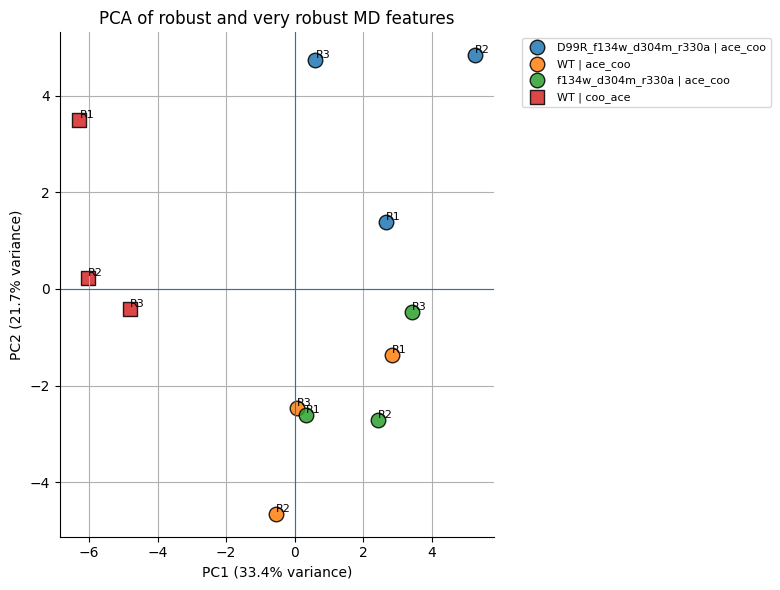


Top PC1-driving features:


,PC1_loading,PC2_loading,abs_PC1,abs_PC2
productive_state_sd,0.260010,0.047297,0.260010,0.047297
productive_distance_sd,0.259981,0.047246,0.259981,0.047246
attack_distance_A_mean,-0.257791,0.014605,0.257791,0.014605
mean_distance_A,-0.257791,0.014605,0.257791,0.014605
polar_contacts_resid_330_sd,-0.254090,0.031127,0.254090,0.031127
min_distance_A,-0.249137,0.078395,0.249137,0.078395
polar_contacts_resid_330_mean,-0.248147,0.074470,0.248147,0.074470
productive_distance_mean,0.230602,0.113101,0.230602,0.113101
productive_fraction,0.230602,0.113101,0.230602,0.113101
productive_state_mean,0.229877,0.113202,0.229877,0.113202



Top PC2-driving features:


,PC1_loading,PC2_loading,abs_PC1,abs_PC2
r330_to_t267_ca_A_sd,0.004587,0.301739,0.004587,0.301739
productive_angle_mean,0.155260,-0.250670,0.155260,0.250670
attack_angle_og1_c_o_deg_mean,0.147765,-0.242585,0.147765,0.242585
d99_to_r330_ca_A_sd,0.090710,0.242277,0.090710,0.242277
substrate_rmsd_A_mean,0.012639,-0.234065,0.012639,0.234065
substrate_rmsd_A_sd,-0.000084,-0.226631,0.000084,0.226631
productive_angle_sd,-0.051643,0.220173,0.051643,0.220173
r330_to_t267_ca_A_mean,-0.043903,-0.210616,0.043903,0.210616
num_polar_contacts_mean,-0.065286,0.206044,0.065286,0.206044
triad_rmsd_A_mean,0.101736,-0.196544,0.101736,0.196544



PCA of very robust MD features only
CV threshold: 0.2
Selected features: 29
Features used after cleaning: 29
PC1 explained variance: 0.351
PC2 explained variance: 0.229


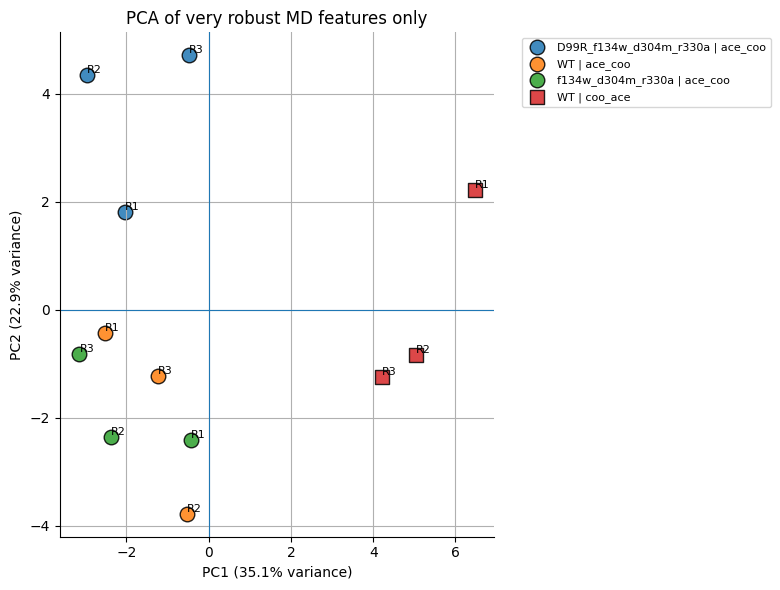


Top PC1-driving features:


,PC1_loading,PC2_loading,abs_PC1,abs_PC2
min_distance_A,0.298228,0.014861,0.298228,0.014861
polar_contacts_resid_330_sd,0.296918,-0.032949,0.296918,0.032949
mean_distance_A,0.294389,-0.059670,0.294389,0.059670
attack_distance_A_mean,0.294389,-0.059670,0.294389,0.059670
productive_state_sd,-0.275144,0.102451,0.275144,0.102451
productive_distance_sd,-0.275103,0.102617,0.275103,0.102617
substrate_end_to_end_A_mean,0.238981,-0.128968,0.238981,0.128968
substrate_end_to_end_A_sd,-0.225942,-0.150936,0.225942,0.150936
num_polar_contacts_sd,0.224271,0.144555,0.224271,0.144555
productive_angle_mean,-0.218802,-0.234512,0.218802,0.234512



Top PC2-driving features:


,PC1_loading,PC2_loading,abs_PC1,abs_PC2
r330_to_t267_ca_A_sd,0.036813,0.355595,0.036813,0.355595
d99_to_r330_ca_A_sd,-0.061792,0.305624,0.061792,0.305624
r330_to_t267_ca_A_mean,0.030779,-0.274354,0.030779,0.274354
substrate_rmsd_A_sd,-0.037153,-0.260963,0.037153,0.260963
d99_to_r330_ca_A_mean,0.077354,-0.250441,0.077354,0.250441
productive_angle_mean,-0.218802,-0.234512,0.218802,0.234512
f134_to_r330_ca_A_sd,-0.127378,0.229297,0.127378,0.229297
triad_rmsd_A_mean,-0.136354,-0.220887,0.136354,0.220887
attack_angle_og1_c_o_deg_mean,-0.209788,-0.218964,0.209788,0.218964
num_polar_contacts_mean,0.118058,0.210762,0.118058,0.210762


In [26]:
# ============================================================
# PCA using robust and very robust MD features
# ============================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def run_pca_for_feature_subset(
    md_feature_df,
    robustness_df,
    cv_threshold,
    title,
    remove_trivial_features=True,
):
    """
    Runs PCA on a subset of MD features selected by replicate robustness.

    Parameters
    ----------
    md_feature_df:
        Replicate-level feature matrix.
    robustness_df:
        Feature robustness table with CV values.
    cv_threshold:
        Maximum allowed CV across replicates.
    title:
        Plot title.
    remove_trivial_features:
        If True, removes features that are usually not biologically informative.
    """

    if md_feature_df.empty:
        print("Feature table is empty.")
        return None, None, None

    if robustness_df.empty:
        print("Robustness table is empty.")
        return None, None, None

    metadata_cols = ["condition", "variant", "replicate"]

    # --------------------------------------------------------
    # Select robust feature names
    # --------------------------------------------------------

    robust_features = (
        robustness_df
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["cv_between_replicates"])
        .copy()
    )

    if "mean_across_replicates" in robust_features.columns:
        robust_features = robust_features[
            robust_features["mean_across_replicates"].abs() > 1e-3
        ]

    robust_features = robust_features[
        robust_features["cv_between_replicates"] < cv_threshold
    ]

    selected_features = sorted(robust_features["feature"].unique())

    # --------------------------------------------------------
    # Remove trivial or weakly informative features
    # --------------------------------------------------------

    if remove_trivial_features:
        trivial_patterns = [
            "n_frames",
            "_max",
            "_min",
        ]

        selected_features = [
            f for f in selected_features
            if not any(pattern in f for pattern in trivial_patterns)
        ]

    # Keep only features that are actually present in the feature table
    selected_features = [
        f for f in selected_features
        if f in md_feature_df.columns
    ]

    print(f"\n{title}")
    print(f"CV threshold: {cv_threshold}")
    print(f"Selected features: {len(selected_features)}")

    if len(selected_features) < 2:
        print("Not enough features for PCA.")
        return None, None, None

    # --------------------------------------------------------
    # Build feature matrix
    # --------------------------------------------------------

    pca_df = md_feature_df.copy()

    metadata = pca_df[metadata_cols].copy()

    X = pca_df[selected_features].copy()

    # Remove columns with only NaN
    X = X.dropna(axis=1, how="all")

    # Fill remaining NaNs with column means
    X = X.fillna(X.mean())

    # Remove zero-variance features
    stds = X.std(axis=0)
    X = X.loc[:, stds > 1e-12]

    if X.shape[1] < 2:
        print("Not enough non-constant features for PCA.")
        return None, None, None

    # --------------------------------------------------------
    # Standardize features
    # --------------------------------------------------------

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --------------------------------------------------------
    # PCA
    # --------------------------------------------------------

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    explained_var = pca.explained_variance_ratio_

    pca_results = metadata.copy()
    pca_results["PC1"] = X_pca[:, 0]
    pca_results["PC2"] = X_pca[:, 1]

    print(f"Features used after cleaning: {X.shape[1]}")
    print(f"PC1 explained variance: {explained_var[0]:.3f}")
    print(f"PC2 explained variance: {explained_var[1]:.3f}")

    # --------------------------------------------------------
    # Plot PCA
    # --------------------------------------------------------

    plt.figure(figsize=(8, 6))

    conditions = sorted(pca_results["condition"].unique())
    markers = ["o", "s", "^", "D", "v", "P", "X"]

    for i, condition_name in enumerate(conditions):

        cond_df = pca_results[
            pca_results["condition"] == condition_name
        ]

        for variant in sorted(cond_df["variant"].unique()):

            var_df = cond_df[
                cond_df["variant"] == variant
            ]

            plt.scatter(
                var_df["PC1"],
                var_df["PC2"],
                s=110,
                marker=markers[i % len(markers)],
                alpha=0.85,
                label=f"{variant} | {condition_name}",
                edgecolor="black",
            )

            for _, row in var_df.iterrows():
                plt.text(
                    row["PC1"],
                    row["PC2"],
                    f"R{int(row['replicate'])}",
                    fontsize=8,
                    ha="left",
                    va="bottom",
                )

    plt.xlabel(f"PC1 ({explained_var[0] * 100:.1f}% variance)")
    plt.ylabel(f"PC2 ({explained_var[1] * 100:.1f}% variance)")
    plt.title(title)

    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)

    plt.legend(
        fontsize=8,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # PCA loadings
    # --------------------------------------------------------

    loading_df = pd.DataFrame(
        pca.components_.T,
        index=X.columns,
        columns=["PC1_loading", "PC2_loading"],
    )

    loading_df["abs_PC1"] = loading_df["PC1_loading"].abs()
    loading_df["abs_PC2"] = loading_df["PC2_loading"].abs()

    print("\nTop PC1-driving features:")
    display(
        loading_df
        .sort_values("abs_PC1", ascending=False)
        .head(20)
    )

    print("\nTop PC2-driving features:")
    display(
        loading_df
        .sort_values("abs_PC2", ascending=False)
        .head(20)
    )

    return pca_results, loading_df, selected_features


# ============================================================
# PCA 1: Robust + very robust features
# CV < 0.5
# ============================================================

pca_robust_results, pca_robust_loadings, robust_selected_features = run_pca_for_feature_subset(
    md_feature_df=md_filter_features_replicate,
    robustness_df=replicate_robustness,
    cv_threshold=0.5,
    title="PCA of robust and very robust MD features",
    remove_trivial_features=True,
)


# ============================================================
# PCA 2: Very robust features only
# CV < 0.2
# ============================================================

pca_very_robust_results, pca_very_robust_loadings, very_robust_selected_features = run_pca_for_feature_subset(
    md_feature_df=md_filter_features_replicate,
    robustness_df=replicate_robustness,
    cv_threshold=0.2,
    title="PCA of very robust MD features only",
    remove_trivial_features=True,
)

In [31]:
# ============================================================
# Interactive hierarchical clustering with selectable metrics
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform

import ipywidgets as widgets
from IPython.display import display, clear_output


# ------------------------------------------------------------
# Metric descriptions
# ------------------------------------------------------------

METRIC_DESCRIPTIONS = {
    "euclidean": """
Euclidean distance measures absolute geometric distance in standardized feature space.
Use this when absolute differences in feature values are biologically meaningful.
Best paired with Ward linkage. Good default for continuous MD features such as distances, RMSD, RMSF and geometry descriptors.
""",
   "cityblock": """
Cityblock distance is the SciPy name for Manhattan distance. It sums absolute feature-wise differences.
Use this when you want a metric that is less dominated by single large deviations than Euclidean distance.
Useful for noisy MD feature sets or when several moderate feature shifts matter more than one large shift.
""",
    "cosine": """
Cosine distance compares the angle between feature vectors rather than their absolute magnitude.
Use this when the relative feature pattern is more important than absolute feature values.
Useful for comparing interaction fingerprints, contact profiles or mechanistic signatures.
""",
    "correlation": """
Correlation distance compares whether two variants show similar feature trends after subtracting their mean profile.
Use this when you care about similar mechanistic patterns, not absolute feature magnitude.
Useful for asking whether two variants behave similarly across the same feature families.
""",
    "canberra": """
Canberra distance gives stronger weight to relative differences in small-valued features.
Use with caution. It can be useful for sparse contact features, but can become unstable when many values are close to zero.
""",
}


LINKAGE_OPTIONS = {
    "ward": ["euclidean"],
    "average": ["euclidean", "cityblock", "cosine", "correlation", "canberra"],
    "complete": ["euclidean", "cityblock", "cosine", "correlation", "canberra"],
    "single": ["euclidean", "cityblock", "cosine", "correlation", "canberra"],
}


# ------------------------------------------------------------
# Prepare robust feature matrix once
# ------------------------------------------------------------

CV_THRESHOLD = 0.5

REMOVE_PATTERNS = [
    "_max",
    "_min",
    "n_frames",
]

robust_features = (
    replicate_robustness
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["cv_between_replicates"])
    .copy()
)

if "mean_across_replicates" in robust_features.columns:
    robust_features = robust_features[
        robust_features["mean_across_replicates"].abs() > 1e-3
    ]

robust_features = robust_features[
    robust_features["cv_between_replicates"] < CV_THRESHOLD
]

selected_features = sorted(robust_features["feature"].unique())

selected_features = [
    f for f in selected_features
    if not any(pattern in f for pattern in REMOVE_PATTERNS)
]

selected_features = [
    f for f in selected_features
    if f in md_filter_features_replicate.columns
]

cluster_df = md_filter_features_replicate.copy()

variant_features = (
    cluster_df
    .groupby(["condition", "variant"], as_index=False)[selected_features]
    .mean()
)

variant_features["label"] = (
    variant_features["variant"]
    + " | "
    + variant_features["condition"]
)

labels = variant_features["label"].tolist()

X = variant_features[selected_features].copy()

X = X.dropna(axis=1, how="all")
X = X.fillna(X.mean())

stds = X.std(axis=0)
X = X.loc[:, stds > 1e-12]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Selected robust features before cleaning: {len(selected_features)}")
print(f"Features used after cleaning: {X.shape[1]}")
print(f"Objects clustered: {len(labels)}")


# ------------------------------------------------------------
# Interactive plotting function
# ------------------------------------------------------------

def plot_interactive_clustering(linkage_method, distance_metric):

    clear_output(wait=True)

    # Validate metric-method combination
    allowed_metrics = LINKAGE_OPTIONS[linkage_method]

    if distance_metric not in allowed_metrics:
        print(
            f"Metric '{distance_metric}' is not compatible with linkage method "
            f"'{linkage_method}'."
        )
        print(f"Allowed metrics: {allowed_metrics}")
        return

    print("Selected clustering setup")
    print("=========================")
    print(f"Linkage method:  {linkage_method}")
    print(f"Distance metric: {distance_metric}")
    print()

    print("How to interpret this metric")
    print("============================")
    print(METRIC_DESCRIPTIONS.get(distance_metric, "No description available."))
    print()

    # --------------------------------------------------------
    # Compute linkage
    # --------------------------------------------------------

    if linkage_method == "ward":
        Z = linkage(
            X_scaled,
            method="ward",
            metric="euclidean",
        )
        distance_matrix = squareform(
            pdist(X_scaled, metric="euclidean")
        )
    else:
        distances = pdist(
            X_scaled,
            metric=distance_metric,
        )

        Z = linkage(
            distances,
            method=linkage_method,
        )

        distance_matrix = squareform(distances)

    # --------------------------------------------------------
    # Dendrogram
    # --------------------------------------------------------

    plt.figure(figsize=(10, 6))

    dendrogram(
        Z,
        labels=labels,
        leaf_rotation=45,
        leaf_font_size=10,
    )

    plt.title(
        "Hierarchical clustering of NylC variants\n"
        f"Linkage: {linkage_method} | Metric: {distance_metric}"
    )

    plt.ylabel("Cluster distance")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Distance heatmap
    # --------------------------------------------------------

    distance_df = pd.DataFrame(
        distance_matrix,
        index=labels,
        columns=labels,
    )

    plt.figure(figsize=(7, 6))

    plt.imshow(distance_df.values, aspect="auto")
    plt.colorbar(label=f"{distance_metric} distance")

    plt.xticks(
        range(len(distance_df.columns)),
        distance_df.columns,
        rotation=45,
        ha="right",
    )

    plt.yticks(
        range(len(distance_df.index)),
        distance_df.index,
    )

    plt.title(
        f"Pairwise distance matrix\nMetric: {distance_metric}"
    )

    plt.tight_layout()
    plt.show()

    print("Pairwise distances:")
    display(distance_df.round(3))


# ------------------------------------------------------------
# Widgets
# ------------------------------------------------------------

linkage_dropdown = widgets.Dropdown(
    options=list(LINKAGE_OPTIONS.keys()),
    value="ward",
    description="Linkage:",
)

metric_dropdown = widgets.Dropdown(
    options=LINKAGE_OPTIONS["ward"],
    value="euclidean",
    description="Metric:",
)


def update_metric_options(*args):
    allowed = LINKAGE_OPTIONS[linkage_dropdown.value]
    metric_dropdown.options = allowed

    if metric_dropdown.value not in allowed:
        metric_dropdown.value = allowed[0]


linkage_dropdown.observe(update_metric_options, names="value")


ui = widgets.HBox([
    linkage_dropdown,
    metric_dropdown,
])

out = widgets.interactive_output(
    plot_interactive_clustering,
    {
        "linkage_method": linkage_dropdown,
        "distance_metric": metric_dropdown,
    },
)

display(ui, out)

Selected robust features before cleaning: 40
Features used after cleaning: 40
Objects clustered: 4


Output()

# 8. Export compact presentation tables

Compact summary tables are created for direct reuse in slides or reports.

In [24]:
presentation_tables = {}

if not score_df.empty and "md_score_v01" in score_df.columns:
    presentation_tables["variant_score_summary"] = (
        score_df.groupby(["condition", "variant"], as_index=False)
        .agg(md_score_mean=("md_score_v01", "mean"), md_score_sd=("md_score_v01", "std"), n_replicates=("replicate", "count"))
        .sort_values(["condition", "md_score_mean"], ascending=[True, False])
    )
    display(presentation_tables["variant_score_summary"])

if not productive_geometry_replicate.empty:
    productive_cols = [c for c in productive_geometry_replicate.columns if "productive" in c or "attack" in c]
    keep_cols = [c for c in ["condition", "variant", "replicate"] + productive_cols if c in productive_geometry_replicate.columns]
    presentation_tables["productive_geometry_summary"] = productive_geometry_replicate[keep_cols]
    display(presentation_tables["productive_geometry_summary"].head())

for name, df in presentation_tables.items():
    out_file = RESULT_DIR / f"{name}.csv"
    df.to_csv(out_file, index=False)
    print(f"Saved {out_file}")


,condition,variant,md_score_mean,md_score_sd,n_replicates
2,ace_coo,f134w_d304m_r330a,0.122607,0.143545,3
0,ace_coo,D99R_f134w_d304m_r330a,0.048459,0.432339,3
1,ace_coo,WT,0.043667,0.260113,3
3,coo_ace,WT,-0.214733,0.280945,3


,condition,variant,replicate,attack_distance_A_mean,attack_angle_og1_c_o_deg_mean,productive_distance_mean,productive_angle_mean,productive_state_mean,attack_distance_A_sd,attack_angle_og1_c_o_deg_sd,...,attack_distance_A_min,attack_angle_og1_c_o_deg_min,productive_distance_min,productive_angle_min,productive_state_min,attack_distance_A_max,attack_angle_og1_c_o_deg_max,productive_distance_max,productive_angle_max,productive_state_max
0,ace_coo,D99R_f134w_d304m_r330a,1,3.829991,137.975307,0.111851,0.976032,0.106525,0.270170,23.330280,...,2.974575,81.253802,False,False,False,4.540554,174.709373,True,True,True
1,ace_coo,D99R_f134w_d304m_r330a,2,4.417265,95.660347,0.279627,0.339547,0.279627,0.832602,42.104467,...,2.802664,48.436898,False,False,False,5.809631,179.167135,True,True,True
2,ace_coo,D99R_f134w_d304m_r330a,3,6.000997,78.327048,0.063915,0.161119,0.063915,0.974725,22.789640,...,3.073838,33.465829,False,False,False,7.649902,176.184101,True,True,True
3,ace_coo,WT,1,3.829369,124.881473,0.135819,0.981358,0.134487,0.400202,14.770248,...,2.933034,73.495562,False,False,False,5.935493,173.379195,True,True,True
4,ace_coo,WT,2,6.358894,140.655194,0.018642,0.992011,0.018642,1.172673,20.203726,...,3.198298,77.822797,False,False,False,8.822487,178.523925,True,True,True


Saved /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/md_feature_analysis/variant_score_summary.csv
Saved /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/md_feature_analysis/productive_geometry_summary.csv


## Feature Space Clustering


Selected features: 40
Features used after cleaning: 40
Systems used: 12


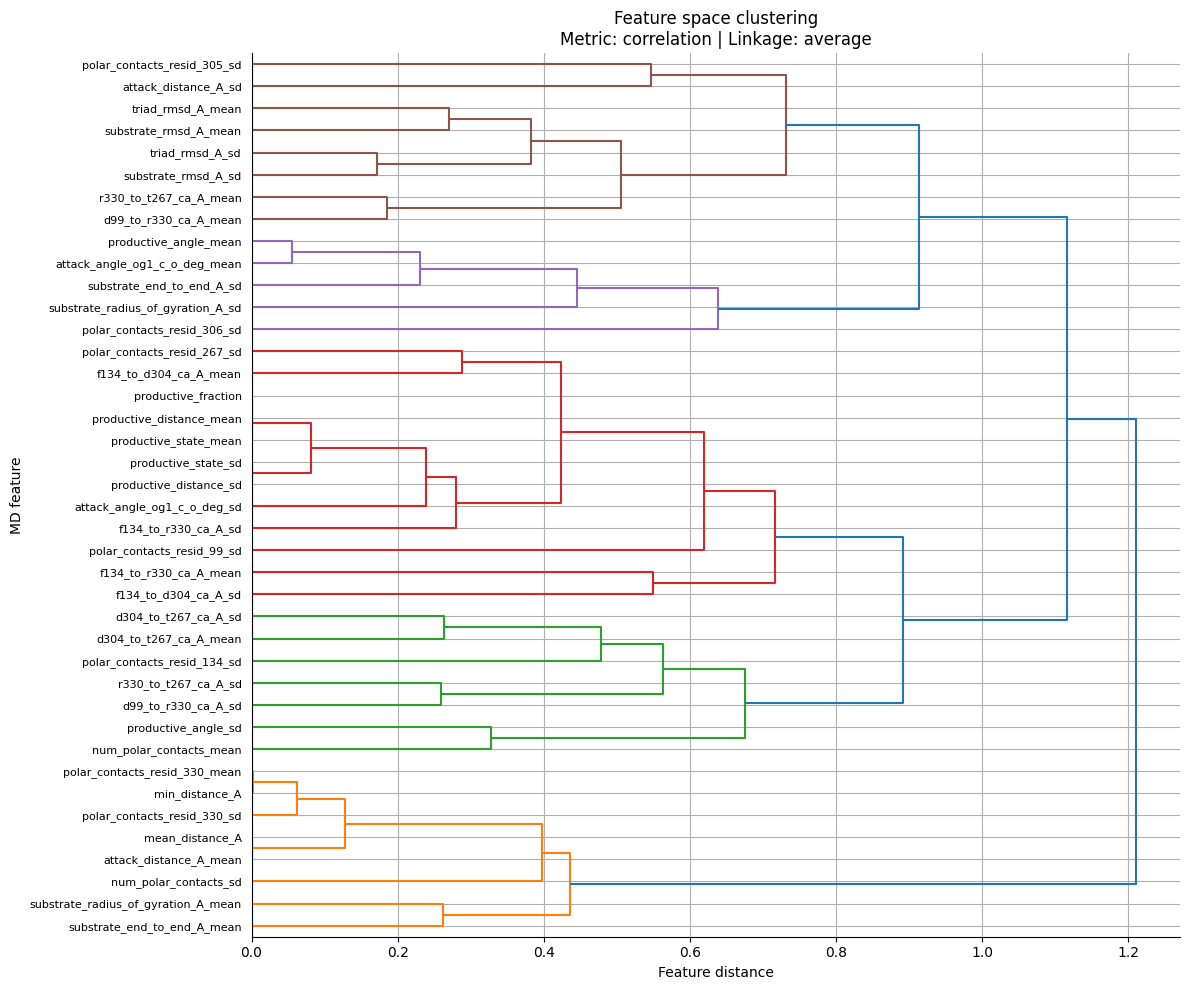

,attack_angle_og1_c_o_deg_mean,attack_angle_og1_c_o_deg_sd,attack_distance_A_mean,attack_distance_A_sd,d304_to_t267_ca_A_mean,d304_to_t267_ca_A_sd,d99_to_r330_ca_A_mean,d99_to_r330_ca_A_sd,f134_to_d304_ca_A_mean,f134_to_d304_ca_A_sd,...,r330_to_t267_ca_A_mean,r330_to_t267_ca_A_sd,substrate_end_to_end_A_mean,substrate_end_to_end_A_sd,substrate_radius_of_gyration_A_mean,substrate_radius_of_gyration_A_sd,substrate_rmsd_A_mean,substrate_rmsd_A_sd,triad_rmsd_A_mean,triad_rmsd_A_sd
attack_angle_og1_c_o_deg_mean,0.000,0.871,1.567,0.531,1.653,1.406,0.917,1.392,0.865,1.431,...,0.858,1.609,1.379,0.234,0.892,0.517,0.618,0.775,0.507,0.956
attack_angle_og1_c_o_deg_sd,0.871,0.000,1.644,0.869,1.389,1.306,1.289,0.522,0.632,0.979,...,1.125,0.677,1.613,0.943,1.677,0.793,1.108,1.179,1.133,1.273
attack_distance_A_mean,1.567,1.644,0.000,1.045,0.426,0.876,0.659,1.281,1.721,0.894,...,0.735,0.981,0.340,1.627,0.623,1.556,1.025,1.010,1.297,1.026
attack_distance_A_sd,0.531,0.869,1.045,0.000,1.174,1.101,0.841,1.071,1.180,1.044,...,0.690,1.202,1.461,0.593,1.287,0.995,0.693,0.698,0.625,0.784
d304_to_t267_ca_A_mean,1.653,1.389,0.426,1.174,0.000,0.264,1.204,0.776,1.232,0.627,...,1.314,0.428,0.949,1.394,1.140,1.462,1.207,1.206,1.302,1.040
d304_to_t267_ca_A_sd,1.406,1.306,0.876,1.101,0.264,0.000,1.310,0.623,0.703,0.361,...,1.401,0.485,1.160,1.032,1.267,1.123,1.209,1.223,0.886,0.882
d99_to_r330_ca_A_mean,0.917,1.289,0.659,0.841,1.204,1.310,0.000,1.421,1.451,1.143,...,0.185,1.518,0.499,1.203,0.550,1.230,0.369,0.443,0.649,0.697
d99_to_r330_ca_A_sd,1.392,0.522,1.281,1.071,0.776,0.623,1.421,0.000,0.568,0.757,...,1.443,0.259,1.418,1.237,1.488,1.442,1.256,1.353,1.212,0.974
f134_to_d304_ca_A_mean,0.865,0.632,1.721,1.180,1.232,0.703,1.451,0.568,0.000,0.518,...,1.621,0.604,1.429,0.699,1.185,0.643,1.429,1.175,0.970,0.975
f134_to_d304_ca_A_sd,1.431,0.979,0.894,1.044,0.627,0.361,1.143,0.757,0.518,0.000,...,1.322,0.398,1.074,1.236,1.232,0.990,1.484,1.234,1.152,1.117


,feature,feature_cluster
2,attack_distance_A_mean,1
12,mean_distance_A,1
13,min_distance_A,1
15,num_polar_contacts_sd,1
20,polar_contacts_resid_330_mean,1
21,polar_contacts_resid_330_sd,1
32,substrate_end_to_end_A_mean,1
34,substrate_radius_of_gyration_A_mean,1
14,num_polar_contacts_mean,2
24,productive_angle_sd,2



Feature cluster 1
attack_distance_A_mean
mean_distance_A
min_distance_A
num_polar_contacts_sd
polar_contacts_resid_330_mean
polar_contacts_resid_330_sd
substrate_end_to_end_A_mean
substrate_radius_of_gyration_A_mean

Feature cluster 2
num_polar_contacts_mean
productive_angle_sd

Feature cluster 3
d304_to_t267_ca_A_mean
d304_to_t267_ca_A_sd
d99_to_r330_ca_A_sd
polar_contacts_resid_134_sd
r330_to_t267_ca_A_sd

Feature cluster 4
f134_to_d304_ca_A_sd
f134_to_r330_ca_A_mean

Feature cluster 5
attack_angle_og1_c_o_deg_sd
f134_to_d304_ca_A_mean
f134_to_r330_ca_A_sd
polar_contacts_resid_267_sd
polar_contacts_resid_99_sd
productive_distance_mean
productive_distance_sd
productive_fraction
productive_state_mean
productive_state_sd

Feature cluster 6
attack_angle_og1_c_o_deg_mean
polar_contacts_resid_306_sd
productive_angle_mean
substrate_end_to_end_A_sd
substrate_radius_of_gyration_A_sd

Feature cluster 7
d99_to_r330_ca_A_mean
r330_to_t267_ca_A_mean
substrate_rmsd_A_mean
substrate_rmsd_A_sd
tria

In [32]:
# ============================================================
# Feature space clustering
# Clusters MD features based on their behavior across variants/replicates
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

CV_THRESHOLD = 0.5

REMOVE_PATTERNS = [
    "_max",
    "_min",
    "n_frames",
]

DISTANCE_METRIC = "correlation"
LINKAGE_METHOD = "average"


# ------------------------------------------------------------
# Select robust features
# ------------------------------------------------------------

robust_features = (
    replicate_robustness
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["cv_between_replicates"])
    .copy()
)

if "mean_across_replicates" in robust_features.columns:
    robust_features = robust_features[
        robust_features["mean_across_replicates"].abs() > 1e-3
    ]

robust_features = robust_features[
    robust_features["cv_between_replicates"] < CV_THRESHOLD
]

selected_features = sorted(robust_features["feature"].unique())

selected_features = [
    f for f in selected_features
    if not any(pattern in f for pattern in REMOVE_PATTERNS)
]

selected_features = [
    f for f in selected_features
    if f in md_filter_features_replicate.columns
]

print(f"Selected features: {len(selected_features)}")


# ------------------------------------------------------------
# Build feature matrix
# Rows = variant/replicate systems
# Columns = features
# ------------------------------------------------------------

metadata_cols = ["condition", "variant", "replicate"]

feature_df = md_filter_features_replicate[
    metadata_cols + selected_features
].copy()

X = feature_df[selected_features].copy()

X = X.dropna(axis=1, how="all")
X = X.fillna(X.mean())

stds = X.std(axis=0)
X = X.loc[:, stds > 1e-12]

print(f"Features used after cleaning: {X.shape[1]}")
print(f"Systems used: {X.shape[0]}")


# ------------------------------------------------------------
# Standardize features across systems
# ------------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=feature_df["variant"] + " | " + feature_df["condition"] + " | R" + feature_df["replicate"].astype(str),
)


# ------------------------------------------------------------
# Transpose matrix for feature clustering
# Rows = features
# Columns = systems
# ------------------------------------------------------------

X_features = X_scaled_df.T


# ------------------------------------------------------------
# Hierarchical clustering of features
# ------------------------------------------------------------

feature_distances = pdist(
    X_features.values,
    metric=DISTANCE_METRIC,
)

Z_features = linkage(
    feature_distances,
    method=LINKAGE_METHOD,
)

plt.figure(figsize=(12, max(8, 0.25 * X_features.shape[0])))

dendrogram(
    Z_features,
    labels=X_features.index.tolist(),
    leaf_rotation=0,
    leaf_font_size=8,
    orientation="right",
)

plt.title(
    f"Feature space clustering\n"
    f"Metric: {DISTANCE_METRIC} | Linkage: {LINKAGE_METHOD}"
)

plt.xlabel("Feature distance")
plt.ylabel("MD feature")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Feature-feature distance matrix
# ------------------------------------------------------------

feature_distance_matrix = squareform(feature_distances)

feature_distance_df = pd.DataFrame(
    feature_distance_matrix,
    index=X_features.index,
    columns=X_features.index,
)

display(feature_distance_df.round(3))


# ------------------------------------------------------------
# Cluster features into groups
# ------------------------------------------------------------

from scipy.cluster.hierarchy import fcluster

N_FEATURE_CLUSTERS = 8

feature_clusters = fcluster(
    Z_features,
    t=N_FEATURE_CLUSTERS,
    criterion="maxclust",
)

feature_cluster_table = pd.DataFrame({
    "feature": X_features.index,
    "feature_cluster": feature_clusters,
})

feature_cluster_table = feature_cluster_table.sort_values(
    ["feature_cluster", "feature"]
)

display(feature_cluster_table)


# ------------------------------------------------------------
# Show features per cluster
# ------------------------------------------------------------

for cluster_id, group in feature_cluster_table.groupby("feature_cluster"):

    print("\n" + "=" * 60)
    print(f"Feature cluster {cluster_id}")
    print("=" * 60)

    for feature in group["feature"]:
        print(feature)

In [35]:
# ============================================================
# Select the 3 most robust features per feature cluster
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Merge cluster assignments with robustness statistics
# ------------------------------------------------------------

clustered_features = feature_cluster_table.merge(
    replicate_robustness,
    on="feature",
    how="left",
)

# ------------------------------------------------------------
# Aggregate robustness per feature
# ------------------------------------------------------------

feature_robustness_summary = (
    clustered_features
    .groupby(
        ["feature_cluster", "feature"],
        as_index=False,
    )
    .agg(
        mean_cv=("cv_between_replicates", "mean"),
        median_cv=("cv_between_replicates", "median"),
        max_cv=("cv_between_replicates", "max"),
        n_entries=("cv_between_replicates", "count"),
    )
)

# ------------------------------------------------------------
# Select top robust features per cluster
# Lower CV = more robust
# ------------------------------------------------------------

TOP_FEATURES_PER_CLUSTER = 3

selected_cluster_features = (
    feature_robustness_summary
    .groupby("feature_cluster", group_keys=False)
    .apply(
        lambda x:
        x.sort_values("mean_cv")
         .head(
             min(
                 TOP_FEATURES_PER_CLUSTER,
                 len(x),
             )
         )
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Sort output
# ------------------------------------------------------------

selected_cluster_features = selected_cluster_features.sort_values(
    ["feature_cluster", "mean_cv"]
)

# ------------------------------------------------------------
# Display selected features
# ------------------------------------------------------------

print("\n======================================================")
print("Selected representative robust features per cluster")
print("======================================================")

display(selected_cluster_features)

# ------------------------------------------------------------
# Print readable cluster summary
# ------------------------------------------------------------

for cluster_id, group in selected_cluster_features.groupby("feature_cluster"):

    print("\n" + "=" * 60)
    print(f"Cluster {cluster_id}")
    print("=" * 60)

    for _, row in group.iterrows():

        print(
            f"{row['feature']:<45} "
            f"mean CV = {row['mean_cv']:.3f}"
        )

# ------------------------------------------------------------
# Create final MVP feature list
# ------------------------------------------------------------

mvp_features = (
    selected_cluster_features["feature"]
    .drop_duplicates()
    .tolist()
)

print("\n======================================================")
print("Final MVP feature set")
print("======================================================")

for feature in mvp_features:
    print(feature)

print(f"\nTotal selected MVP features: {len(mvp_features)}")

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

from pathlib import Path

OUT_DIR = Path("/home/dwp46550/ba_nylon/results/md_feature_analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using output directory: {OUT_DIR}")

# ------------------------------------------------------------
# Optional: save outputs
# ------------------------------------------------------------

selected_cluster_features.to_csv(
    OUT_DIR / "selected_cluster_representative_features.csv",
    index=False,
)

pd.DataFrame({
    "mvp_feature": mvp_features
}).to_csv(
    OUT_DIR / "mvp_feature_set.csv",
    index=False,
)

print("\nSaved:")
print(" - selected_cluster_representative_features.csv")
print(" - mvp_feature_set.csv")


Selected representative robust features per cluster


/w0/tmp/slurm_dwp46550.541736/ipykernel_199985/1780286288.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  feature_robustness_summary


,feature_cluster,feature,mean_cv,median_cv,max_cv,n_entries
0,1,substrate_radius_of_gyration_A_mean,0.052445,0.043209,0.090785,4
1,1,min_distance_A,0.068853,0.046668,0.159326,4
2,1,substrate_end_to_end_A_mean,0.118982,0.110361,0.191937,4
3,2,num_polar_contacts_mean,0.272729,0.230698,0.476161,4
4,2,productive_angle_sd,0.713652,0.721053,0.919566,4
5,3,d304_to_t267_ca_A_mean,0.035518,0.035064,0.066204,4
6,3,d99_to_r330_ca_A_sd,0.162384,0.166715,0.237746,4
7,3,r330_to_t267_ca_A_sd,0.258331,0.240223,0.464171,4
8,4,f134_to_r330_ca_A_mean,0.030618,0.033910,0.041223,4
9,4,f134_to_d304_ca_A_sd,0.253516,0.203073,0.457935,4



Cluster 1
substrate_radius_of_gyration_A_mean           mean CV = 0.052
min_distance_A                                mean CV = 0.069
substrate_end_to_end_A_mean                   mean CV = 0.119

Cluster 2
num_polar_contacts_mean                       mean CV = 0.273
productive_angle_sd                           mean CV = 0.714

Cluster 3
d304_to_t267_ca_A_mean                        mean CV = 0.036
d99_to_r330_ca_A_sd                           mean CV = 0.162
r330_to_t267_ca_A_sd                          mean CV = 0.258

Cluster 4
f134_to_r330_ca_A_mean                        mean CV = 0.031
f134_to_d304_ca_A_sd                          mean CV = 0.254

Cluster 5
f134_to_d304_ca_A_mean                        mean CV = 0.039
f134_to_r330_ca_A_sd                          mean CV = 0.140
attack_angle_og1_c_o_deg_sd                   mean CV = 0.233

Cluster 6
substrate_end_to_end_A_sd                     mean CV = 0.107
attack_angle_og1_c_o_deg_mean                 mean CV = 0.149
subs